# Volve open-data full field development with OPM Flow and NeqSim

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/fielddevelopment/volve_full_field_development_opm_neqsim.ipynb)

This long-form engineering tutorial connects a **reservoir-development decision** to
wells, SURF, topsides, emissions, schedule, and economics. It uses Equinor's Volve
open-data release as the field context and provenance anchor. A compact, deterministic
Volve-inspired sector model is generated in the notebook so every reader can run the
complete workflow in a clean Google Colab session.

The reduced model is **not a Volve history match or reserves estimate**. Users with the
full Volve simulation package can point the import adapter at those files and reuse the
same analysis interfaces. All cost and design values are transparent educational
assumptions in constant 2026 USD.


## Learning outcomes and decisions

By the end of the notebook you can:

1. characterize an oil fluid in NeqSim and create OPM Flow black-oil tables;
2. run competing producer/injector counts and well placements in OPM Flow;
3. inspect pressure, saturation, production, recovery, and placement diagnostics;
4. screen tubing, vertical lift, subsea manifolds, flowlines, and risers;
5. turn OPM oil, gas, and water rates into characterized NeqSim process feeds;
6. size a three-stage oil and gas topside process over field life;
7. compare integrated development concepts using capacity, CAPEX, OPEX, NPV,
   break-even price, schedule, emissions, and uncertainty; and
8. identify which conclusions require a full Volve model, calibrated well model,
   dynamic multiphase simulation, or formal project assurance.


## Integrated calculation architecture

The workflow keeps the interfaces between disciplines explicit:

`Volve context → NeqSim PVT → OPM Flow → well model → SURF network →
NeqSim topsides → capacity and emissions → economics and uncertainty`

OPM Flow advances the black-oil conservation equations. In compact form,

$$

\frac{\partial M_\alpha}{\partial t}
+ \nabla \cdot \left(\rho_\alpha \mathbf{u}_\alpha\right)
= q_\alpha

$$

where $M_\alpha$ is phase inventory, $\rho_\alpha$ is density,
$\mathbf{u}_\alpha$ is Darcy velocity, and $q_\alpha$ is a source or sink.
NeqSim supplies phase behavior and surface-process properties; it is not used as a
substitute for the reservoir material-balance solution.


## Volve open-data provenance and responsible use

Equinor released the complete Volve field dataset for research, study, and
development. The release contains about 40,000 files from the 2008–2016 production
period and includes subsurface, well, production, and operating data. The associated
open-data licence describes input and result data from the PDO 2005 and Full Field
simulation models.

Primary sources:

- [Equinor Volve data sharing](https://www.equinor.com/energy/volve-data-sharing)
- [Equinor Open Data Licence for Volve](https://www.equinor.com/content/dam/statoil/documents/what-we-do/Equinor-HRS-Terms-and-conditions-for-licence-to-data-Volve.pdf)
- [OPM Flow](https://opm-project.org/?page_id=19)
- [OPM binary installation](https://opm-project.org/?page_id=245)

**Data boundary.** This repository does not redistribute the multi-gigabyte Volve
package. The executable sector model below uses public field context and clearly
labelled screening assumptions. It avoids proprietary information and is designed
to be replaced by the user's licensed Volve deck without changing downstream APIs.


## Clean-runtime installation

The cell pins the Python interfaces used for validation. In a standard Ubuntu Colab
runtime it installs the official OPM Flow binary package from the OPM PPA. A local
validation environment may provide `OPM_FLOW_EXECUTABLE` instead.


In [1]:
import importlib.util
from importlib.metadata import PackageNotFoundError, version
import os
from pathlib import Path
import platform
import re
import shutil
import subprocess
import sys


REQUIRED_PACKAGES = {
    "neqsim": "3.16.0",
    "opm": "2026.4",
}


def installed_version(package_name):
    try:
        return version(package_name)
    except PackageNotFoundError:
        return None


packages_need_install = any(
    installed_version(package_name) != required_version
    for package_name, required_version in REQUIRED_PACKAGES.items()
)
if packages_need_install:
    package_specs = [
        f"{package_name}=={required_version}"
        for package_name, required_version in REQUIRED_PACKAGES.items()
    ]
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            *package_specs,
        ],
        check=True,
        timeout=900,
    )

FLOW_RUN_ENV = os.environ.copy()
if os.environ.get("OPM_FLOW_PYTHONHOME"):
    FLOW_RUN_ENV["PYTHONHOME"] = os.environ["OPM_FLOW_PYTHONHOME"]

FLOW_EXECUTABLE = os.environ.get("OPM_FLOW_EXECUTABLE")
if FLOW_EXECUTABLE is None:
    FLOW_EXECUTABLE = shutil.which("flow")

if FLOW_EXECUTABLE is None:
    os_release = Path("/etc/os-release").read_text(encoding="utf-8")
    if "Ubuntu" not in os_release:
        raise RuntimeError(
            "The automatic OPM Flow installation requires Ubuntu."
        )
    setup_commands = [
        ["apt-get", "update", "-qq"],
        [
            "apt-get",
            "install",
            "-y",
            "-qq",
            "--no-install-recommends",
            "software-properties-common",
        ],
        ["add-apt-repository", "-y", "ppa:opm/ppa"],
        ["apt-get", "update", "-qq"],
        [
            "apt-get",
            "install",
            "-y",
            "-qq",
            "--no-install-recommends",
            "libopm-simulators-bin",
        ],
    ]
    for setup_command in setup_commands:
        completed_setup = subprocess.run(
            setup_command,
            capture_output=True,
            text=True,
            timeout=1200,
        )
        if completed_setup.returncode != 0:
            raise RuntimeError(
                "OPM Flow installation failed:\n"
                + completed_setup.stderr[-4000:]
            )
    FLOW_EXECUTABLE = shutil.which("flow")

if FLOW_EXECUTABLE is None:
    raise RuntimeError("OPM Flow executable was not found.")

flow_version_run = subprocess.run(
    [FLOW_EXECUTABLE, "--version"],
    capture_output=True,
    env=FLOW_RUN_ENV,
    check=True,
    text=True,
    timeout=60,
)
flow_version_text = flow_version_run.stdout + flow_version_run.stderr
flow_version_match = re.search(
    r"flow\s+(\d{4}\.\d{2})",
    flow_version_text,
)
if flow_version_match is None:
    raise RuntimeError("Could not identify the OPM Flow version.")

print(
    {
        "Python": platform.python_version(),
        "NeqSim": installed_version("neqsim"),
        "OPM Python": installed_version("opm"),
        "OPM Flow": flow_version_match.group(1),
    }
)


{'Python': '3.12.13', 'NeqSim': '3.16.0', 'OPM Python': '2026.4', 'OPM Flow': '2026.04'}


## Imports, units, and reproducibility controls

Pressure is absolute and reported in bara. Liquid rates are standard cubic metres per
day, gas rates are standard cubic metres per day, and mass rates are kg/s. The random
seed fixes geological textures and economic uncertainty samples.


In [2]:
import json
import math

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import pandas as pd
from scipy.optimize import brentq
from scipy.stats import spearmanr

from neqsim import jneqsim
from neqsim.thermo import TPflash
from neqsim.process.processTools import (
    clearProcess,
    compressor,
    cooler,
    mixer,
    runProcess,
    separator,
    separator3phase,
    stream,
    valve,
)
from opm.io import Parser
from opm.io.ecl import EclFile, EGrid, ERst, ESmry


plt.style.use("seaborn-v0_8-whitegrid")
RANDOM_SEED = 20260728
random_generator = np.random.default_rng(RANDOM_SEED)

SECONDS_PER_DAY = 86400.0
DAYS_PER_YEAR = 365.25
STANDARD_TEMPERATURE_C = 15.0
STANDARD_PRESSURE_BARA = 1.01325
RESERVOIR_TEMPERATURE_C = 97.5
RESERVOIR_TEMPERATURE_K = RESERVOIR_TEMPERATURE_C + 273.15
INITIAL_RESERVOIR_PRESSURE_BARA = 260.0
PRODUCER_BHP_LIMIT_BARA = 80.0

OUTPUT_DIRECTORY = Path("volve_field_development_outputs")
if OUTPUT_DIRECTORY.exists():
    shutil.rmtree(OUTPUT_DIRECTORY)
OUTPUT_DIRECTORY.mkdir()


mkdir -p failed for path /root/.config/matplotlib: [Errno 30] Read-only file system: '/root/.config'
Matplotlib created a temporary cache directory at /tmp/matplotlib-yxryrkqc because there was an issue with the default path (/root/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


## Field basis: public context versus screening assumptions

The table distinguishes source types. Field name and production period are public
context. Grid size, petrophysics, well targets, costs, and process conditions are
explicit educational assumptions selected for a fast, stable Colab run.


In [3]:
field_basis = pd.DataFrame(
    [
        {
            "item": "field context",
            "value": "Volve, Norwegian North Sea",
            "unit": "-",
            "provenance": "Equinor open-data release",
        },
        {
            "item": "public production period",
            "value": "2008–2016",
            "unit": "calendar years",
            "provenance": "Equinor open-data release",
        },
        {
            "item": "simulation grid",
            "value": "16 × 16 × 3",
            "unit": "active cells",
            "provenance": "reduced teaching model",
        },
        {
            "item": "cell dimensions",
            "value": "100 × 100 × 10",
            "unit": "m",
            "provenance": "screening assumption",
        },
        {
            "item": "initial pressure",
            "value": INITIAL_RESERVOIR_PRESSURE_BARA,
            "unit": "bara",
            "provenance": "screening assumption",
        },
        {
            "item": "temperature",
            "value": RESERVOIR_TEMPERATURE_C,
            "unit": "°C",
            "provenance": "screening assumption",
        },
        {
            "item": "forecast duration",
            "value": 8,
            "unit": "years",
            "provenance": "matches public production-period length",
        },
    ]
)
display(field_basis)


,item,value,unit,provenance
0,field context,"Volve, Norwegian North Sea",-,Equinor open-data release
1,public production period,2008–2016,calendar years,Equinor open-data release
2,simulation grid,16 × 16 × 3,active cells,reduced teaching model
3,cell dimensions,100 × 100 × 10,m,screening assumption
4,initial pressure,260.0,bara,screening assumption
5,temperature,97.5,°C,screening assumption
6,forecast duration,8,years,matches public production-period length


## Adapter for the full Volve download

Set `VOLVE_DATA_ROOT` to the extracted Equinor package in Colab, Google Drive, or a
workstation. The adapter inventories Eclipse-format files without changing them.
The reduced case remains the default because a full-field run is too large for a
deterministic teaching notebook and data-access paths differ between users.


In [4]:
volve_data_root = Path(
    os.environ.get("VOLVE_DATA_ROOT", "/content/volve")
)
volve_file_patterns = {
    "DATA decks": "*.DATA",
    "grids": "*.EGRID",
    "restart files": "*.UNRST",
    "summary specifications": "*.SMSPEC",
    "production CSV files": "*.csv",
}

volve_inventory_rows = []
for file_group, file_pattern in volve_file_patterns.items():
    matching_files = (
        list(volve_data_root.rglob(file_pattern))
        if volve_data_root.exists()
        else []
    )
    volve_inventory_rows.append(
        {
            "file group": file_group,
            "count": len(matching_files),
            "example": (
                str(matching_files[0])
                if matching_files
                else "not mounted in this runtime"
            ),
        }
    )

volve_inventory = pd.DataFrame(volve_inventory_rows)
display(volve_inventory)
print(
    "Full Volve package detected:"
    f" {bool(volve_inventory['count'].sum())}"
)


Full Volve package detected: False


,file group,count,example
0,DATA decks,0,not mounted in this runtime
1,grids,0,not mounted in this runtime
2,restart files,0,not mounted in this runtime
3,summary specifications,0,not mounted in this runtime
4,production CSV files,0,not mounted in this runtime


## Reduced reservoir geometry and heterogeneous property model

Two sinuous high-permeability trends and lower-quality background rock create a
meaningful placement problem. Layer multipliers introduce vertical heterogeneity.
The generated arrays are passed directly into the OPM deck and plotted before any
simulation is run.


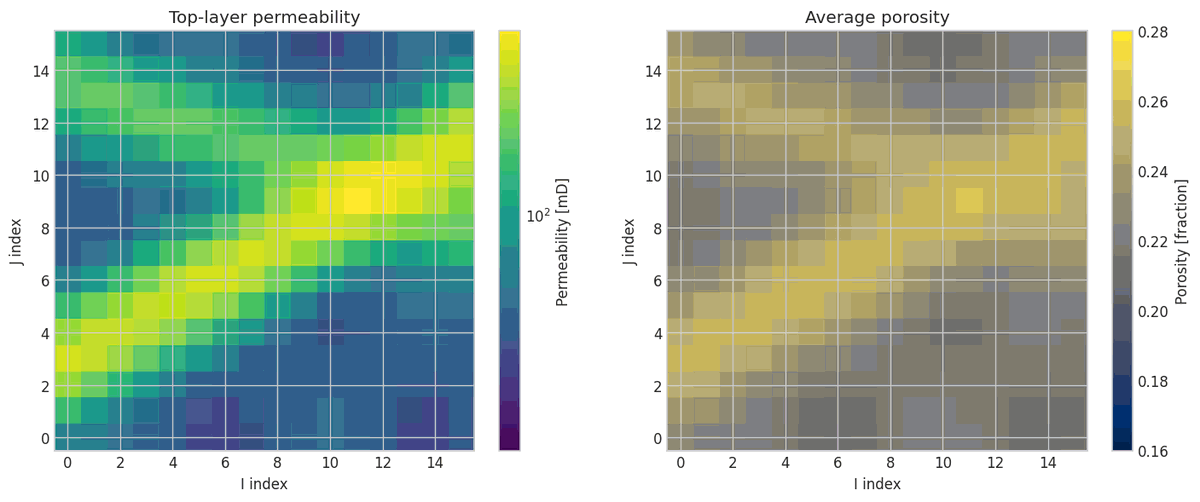

In [5]:
GRID_NX = 16
GRID_NY = 16
GRID_NZ = 3
CELL_DX_M = 100.0
CELL_DY_M = 100.0
LAYER_THICKNESS_M = np.array([8.0, 12.0, 10.0])

x_index = np.arange(GRID_NX)
y_index = np.arange(GRID_NY)
x_mesh, y_mesh = np.meshgrid(x_index, y_index)

channel_one_center = 3.0 + 0.55 * x_mesh
channel_two_center = 13.5 - 0.35 * x_mesh
channel_one = np.exp(
    -((y_mesh - channel_one_center) ** 2) / 3.5
)
channel_two = 0.75 * np.exp(
    -((y_mesh - channel_two_center) ** 2) / 2.8
)
deterministic_texture = (
    0.12
    * np.sin(0.8 * x_mesh)
    * np.cos(0.6 * y_mesh)
)
permeability_map_md = np.clip(
    35.0
    + 380.0 * channel_one
    + 240.0 * channel_two
    + 80.0 * deterministic_texture,
    15.0,
    700.0,
)
layer_multipliers = np.array([1.0, 0.42, 0.72])
permeability_cube_md = np.stack(
    [
        permeability_map_md * layer_multiplier
        for layer_multiplier in layer_multipliers
    ]
)
porosity_cube = np.clip(
    0.17 + 0.035 * np.log10(permeability_cube_md),
    0.16,
    0.28,
)
permeability_y_cube_md = 0.75 * permeability_cube_md
permeability_z_cube_md = 0.07 * permeability_cube_md

property_figure, property_axes = plt.subplots(
    1,
    2,
    figsize=(12.0, 4.8),
    constrained_layout=True,
)
permeability_image = property_axes[0].imshow(
    permeability_cube_md[0],
    origin="lower",
    cmap="viridis",
    norm=LogNorm(
        vmin=permeability_cube_md.min(),
        vmax=permeability_cube_md.max(),
    ),
)
property_axes[0].set_title("Top-layer permeability")
property_axes[0].set_xlabel("I index")
property_axes[0].set_ylabel("J index")
property_figure.colorbar(
    permeability_image,
    ax=property_axes[0],
    label="Permeability [mD]",
)

porosity_image = property_axes[1].imshow(
    porosity_cube.mean(axis=0),
    origin="lower",
    cmap="cividis",
    vmin=0.16,
    vmax=0.28,
)
property_axes[1].set_title("Average porosity")
property_axes[1].set_xlabel("I index")
property_axes[1].set_ylabel("J index")
property_figure.colorbar(
    porosity_image,
    ax=property_axes[1],
    label="Porosity [fraction]",
)
plt.show()


## Candidate well counts and placements

Four cases separate count from placement:

- `3P1I_sparse`: low-cost, sparse development;
- `5P2I_targeted`: five producers deliberately follow high-quality trends;
- `5P2I_regular`: the same well count on a regular pattern, providing a placement test;
- `7P3I_dense`: high-contact, high-CAPEX development.

Coordinates are one-based OPM indices. Every well completes all three layers.


In [6]:
DEVELOPMENT_SCENARIOS = {
    "3P1I_sparse": {
        "producers": [(4, 4), (13, 5), (9, 13)],
        "injectors": [(8, 8)],
    },
    "5P2I_targeted": {
        "producers": [
            (4, 5),
            (7, 7),
            (10, 9),
            (13, 10),
            (7, 13),
        ],
        "injectors": [(3, 11), (12, 4)],
    },
    "5P2I_regular": {
        "producers": [
            (3, 3),
            (8, 3),
            (13, 3),
            (5, 14),
            (12, 14),
        ],
        "injectors": [(8, 8), (14, 8)],
    },
    "7P3I_dense": {
        "producers": [
            (3, 5),
            (5, 6),
            (7, 7),
            (9, 8),
            (11, 9),
            (13, 10),
            (7, 13),
        ],
        "injectors": [(3, 11), (10, 4), (14, 14)],
    },
}


def permeability_at_location(location):
    i_index, j_index = location
    return float(permeability_cube_md[0, j_index - 1, i_index - 1])


placement_rows = []
for scenario_name, scenario_definition in DEVELOPMENT_SCENARIOS.items():
    producer_permeabilities = [
        permeability_at_location(location)
        for location in scenario_definition["producers"]
    ]
    placement_rows.append(
        {
            "scenario": scenario_name,
            "producers": len(scenario_definition["producers"]),
            "injectors": len(scenario_definition["injectors"]),
            "mean producer permeability [mD]": np.mean(
                producer_permeabilities
            ),
            "minimum producer permeability [mD]": np.min(
                producer_permeabilities
            ),
        }
    )

placement_table = pd.DataFrame(placement_rows)
display(placement_table)


,scenario,producers,injectors,mean producer permeability [mD],minimum producer permeability [mD]
0,3P1I_sparse,3,1,126.466625,36.290779
1,5P2I_targeted,5,2,391.996665,187.500704
2,5P2I_regular,5,2,85.330296,33.262211
3,7P3I_dense,7,3,400.315854,187.500704


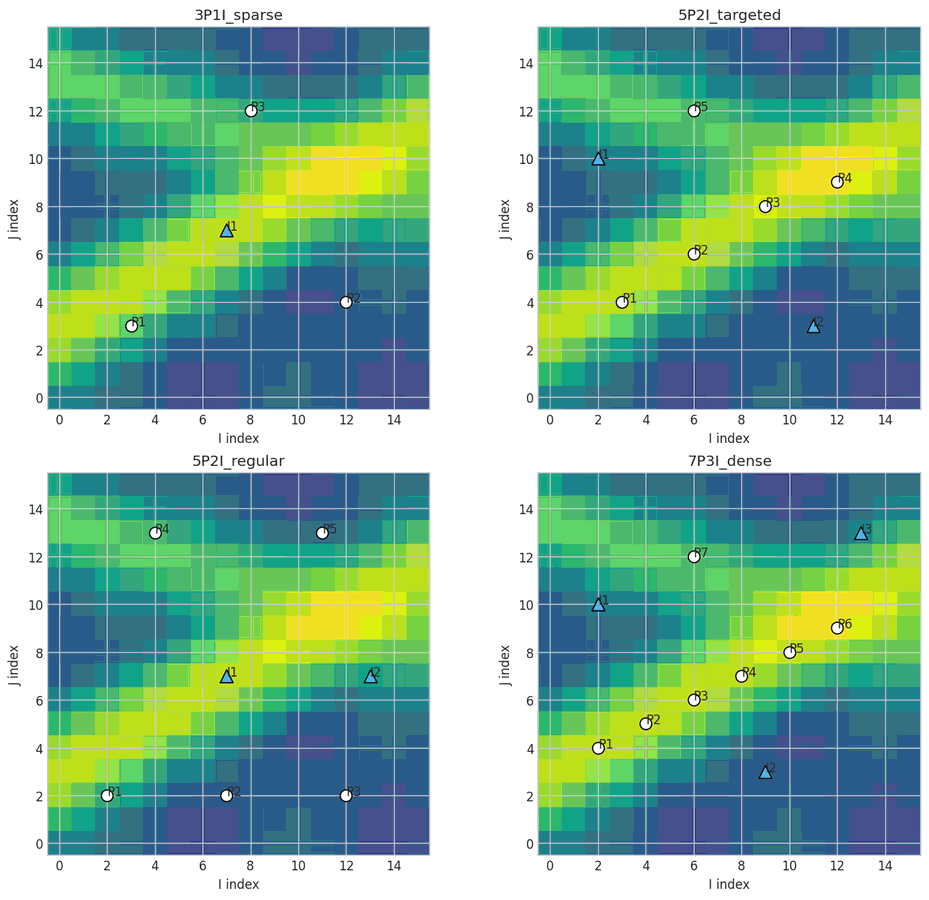

In [7]:
placement_figure, placement_axes = plt.subplots(
    2,
    2,
    figsize=(11.0, 10.0),
    constrained_layout=True,
)

for axis, (
    scenario_name,
    scenario_definition,
) in zip(placement_axes.ravel(), DEVELOPMENT_SCENARIOS.items()):
    axis.imshow(
        permeability_cube_md[0],
        origin="lower",
        cmap="viridis",
        norm=LogNorm(
            vmin=permeability_cube_md.min(),
            vmax=permeability_cube_md.max(),
        ),
    )
    for well_index, (i_index, j_index) in enumerate(
        scenario_definition["producers"],
        start=1,
    ):
        axis.scatter(
            i_index - 1,
            j_index - 1,
            marker="o",
            s=90,
            facecolor="white",
            edgecolor="black",
        )
        axis.text(i_index - 1, j_index - 1, f"P{well_index}")
    for well_index, (i_index, j_index) in enumerate(
        scenario_definition["injectors"],
        start=1,
    ):
        axis.scatter(
            i_index - 1,
            j_index - 1,
            marker="^",
            s=110,
            facecolor="#56B4E9",
            edgecolor="black",
        )
        axis.text(i_index - 1, j_index - 1, f"I{well_index}")
    axis.set_title(scenario_name)
    axis.set_xlabel("I index")
    axis.set_ylabel("J index")

plt.show()


## NeqSim reservoir-fluid characterization

The assay is a public-domain teaching composition previously used in the repository's
OPM coupling example. It is a Volve-like oil, not a claim about a specific Volve PVT
sample. SRK with classic mixing, volume correction, TBP cuts, and a characterized C20+
fraction is used. Composition closure and saturation pressure are audited.


In [8]:
LIGHT_COMPONENTS = [
    ("nitrogen", 0.39),
    ("CO2", 0.30),
    ("methane", 40.20),
    ("ethane", 7.61),
    ("propane", 7.95),
    ("i-butane", 1.19),
    ("n-butane", 4.08),
    ("i-pentane", 1.39),
    ("n-pentane", 2.15),
    ("n-hexane", 2.79),
]
TBP_CUTS = [
    ("C7", 4.28, 0.095, 0.729),
    ("C8", 4.31, 0.106, 0.749),
    ("C9", 3.08, 0.121, 0.770),
    ("C10", 2.47, 0.135, 0.786),
    ("C11", 1.91, 0.148, 0.792),
    ("C12", 1.69, 0.161, 0.804),
    ("C13", 1.59, 0.175, 0.819),
    ("C14", 1.22, 0.196, 0.833),
    ("C15", 1.25, 0.206, 0.836),
    ("C16", 1.00, 0.225, 0.843),
    ("C17", 0.99, 0.236, 0.840),
    ("C18", 0.92, 0.245, 0.846),
    ("C19", 0.60, 0.265, 0.857),
]
PLUS_FRACTION = ("C20", 6.64, 0.453, 0.918)


def build_reservoir_fluid():
    fluid_model = jneqsim.thermo.system.SystemSrkEos(
        RESERVOIR_TEMPERATURE_K,
        INITIAL_RESERVOIR_PRESSURE_BARA,
    )
    for component_name, amount_mol_percent in LIGHT_COMPONENTS:
        fluid_model.addComponent(
            component_name,
            amount_mol_percent,
        )
    for cut_name, amount, molar_mass, relative_density in TBP_CUTS:
        fluid_model.addTBPfraction(
            cut_name,
            amount,
            molar_mass,
            relative_density,
        )
    plus_name, plus_amount, plus_molar_mass, plus_density = PLUS_FRACTION
    fluid_model.addPlusFraction(
        plus_name,
        plus_amount,
        plus_molar_mass,
        plus_density,
    )
    characterization = fluid_model.getCharacterization()
    characterization.getLumpingModel().setNumberOfPseudoComponents(12)
    characterization.characterisePlusFraction()
    fluid_model.setMixingRule("classic")
    fluid_model.useVolumeCorrection(True)
    fluid_model.init(0)
    fluid_model.init(1)
    return fluid_model


reservoir_fluid = build_reservoir_fluid()
assay_sum_mol_percent = (
    sum(amount for _, amount in LIGHT_COMPONENTS)
    + sum(row[1] for row in TBP_CUTS)
    + PLUS_FRACTION[1]
)

saturation_pressure_calculation = (
    jneqsim.pvtsimulation.simulation.SaturationPressure(
        reservoir_fluid.clone()
    )
)
saturation_pressure_calculation.setTemperature(
    RESERVOIR_TEMPERATURE_C,
    "C",
)
saturation_pressure_calculation.run()
saturation_pressure_bara = float(
    saturation_pressure_calculation.getSaturationPressure()
)

fluid_audit = pd.DataFrame(
    {
        "quantity": [
            "input assay closure",
            "characterized components",
            "saturation pressure",
            "EOS",
            "mixing rule",
        ],
        "value": [
            assay_sum_mol_percent,
            reservoir_fluid.getNumberOfComponents(),
            saturation_pressure_bara,
            "SRK",
            "classic",
        ],
        "unit": ["mol%", "count", "bara", "-", "-"],
    }
)
display(fluid_audit)


,quantity,value,unit
0,input assay closure,100.0,mol%
1,characterized components,22,count
2,saturation pressure,193.240934,bara
3,EOS,SRK,-
4,mixing rule,classic,-


## NeqSim differential liberation and black-oil source table

Differential liberation supplies pressure-dependent solution GOR, oil formation
volume factor, density, and viscosity. Gas and water properties are calculated from
phase-specific NeqSim systems. The table is then converted to strict OPM `PVTO`,
`PVDG`, and `PVTW` syntax.


In [9]:
DLE_PRESSURES_BARA = np.array(
    [300.0, 250.0, 220.0, 200.0, 180.0, 150.0, 100.0, 50.0, 1.01325]
)
GAS_PVT_PRESSURES_BARA = np.array(
    [
        1.01325,
        25.0,
        50.0,
        75.0,
        100.0,
        125.0,
        150.0,
        175.0,
        200.0,
        225.0,
        250.0,
        275.0,
        300.0,
    ]
)

DifferentialLiberation = (
    jneqsim.pvtsimulation.simulation.DifferentialLiberation
)
differential_liberation = DifferentialLiberation(
    reservoir_fluid.clone()
)
differential_liberation.setPressures(DLE_PRESSURES_BARA.tolist())
differential_liberation.setTemperature(
    RESERVOIR_TEMPERATURE_C,
    "C",
)
differential_liberation.runCalc()

bubble_pressure_bara = float(
    differential_liberation.getSaturationPressure()
)
dle_rs = np.asarray(differential_liberation.getRs(), dtype=float)
dle_bo = np.asarray(differential_liberation.getBo(), dtype=float)
dle_bg = np.asarray(differential_liberation.getBg(), dtype=float)
dle_oil_density_kg_m3 = np.asarray(
    differential_liberation.getOilDensity(),
    dtype=float,
)

saturation_gas_state = reservoir_fluid.clone()
saturation_gas_state.setTemperature(RESERVOIR_TEMPERATURE_C, "C")
saturation_gas_state.setPressure(bubble_pressure_bara * 0.99, "bara")
TPflash(saturation_gas_state)
saturation_gas_state.initPhysicalProperties()
saturation_gas_viscosity_cp = (
    saturation_gas_state.getPhase("gas").getViscosity("cP")
)

black_oil_rows = []
for pressure_bara, rs_value, bo_value, bg_value, oil_density in zip(
    DLE_PRESSURES_BARA,
    dle_rs,
    dle_bo,
    dle_bg,
    dle_oil_density_kg_m3,
):
    property_state = reservoir_fluid.clone()
    property_state.setTemperature(RESERVOIR_TEMPERATURE_C, "C")
    property_state.setPressure(float(pressure_bara), "bara")
    TPflash(property_state)
    property_state.initPhysicalProperties()
    oil_viscosity_cp = (
        property_state.getPhase("oil").getViscosity("cP")
    )
    gas_viscosity_cp = saturation_gas_viscosity_cp
    if property_state.hasPhaseType("gas"):
        gas_viscosity_cp = (
            property_state.getPhase("gas").getViscosity("cP")
        )
    black_oil_rows.append(
        {
            "pressure_bara": float(pressure_bara),
            "Rs_Sm3_Sm3": float(rs_value),
            "Bo_rm3_Sm3": float(bo_value),
            "oil_density_kg_m3": float(oil_density),
            "oil_viscosity_cP": float(oil_viscosity_cp),
            "DLE_Bg_rm3_Sm3": float(bg_value),
            "gas_viscosity_cP": float(gas_viscosity_cp),
        }
    )

black_oil_source_table = pd.DataFrame(black_oil_rows)
display(black_oil_source_table)
print(f"Bubble pressure: {bubble_pressure_bara:.3f} bara")


Bubble pressure: 193.188 bara


,pressure_bara,Rs_Sm3_Sm3,Bo_rm3_Sm3,oil_density_kg_m3,oil_viscosity_cP,DLE_Bg_rm3_Sm3,gas_viscosity_cP
0,300.00000,224.672710,1.764295,669.030434,0.251013,0.000000,0.021243
1,250.00000,224.672710,1.789529,659.596213,0.235980,0.000000,0.021243
2,220.00000,224.672710,1.806786,653.296398,0.226502,0.000000,0.021243
3,200.00000,224.672710,1.819362,648.780648,0.219967,0.000000,0.021243
4,180.00000,209.018255,1.779300,654.830007,0.230365,0.006301,0.020399
5,150.00000,176.526158,1.687488,672.151167,0.263080,0.007562,0.018454
6,100.00000,128.971246,1.552728,701.626800,0.336558,0.011533,0.015971
7,50.00000,86.277567,1.427528,733.148153,0.461901,0.023873,0.014126
8,1.01325,0.000000,1.050859,810.424578,1.955226,1.271652,0.011572


In [10]:
stock_tank_state = reservoir_fluid.clone()
stock_tank_state.setTemperature(STANDARD_TEMPERATURE_C, "C")
stock_tank_state.setPressure(STANDARD_PRESSURE_BARA, "bara")
TPflash(stock_tank_state)
stock_tank_state.initPhysicalProperties()

stock_oil_density_kg_m3 = (
    stock_tank_state.getPhase("oil").getDensity("kg/m3")
)
stock_gas_density_kg_m3 = (
    stock_tank_state.getPhase("gas").getDensity("kg/m3")
)

bubble_bo = float(
    np.interp(
        bubble_pressure_bara,
        np.sort(DLE_PRESSURES_BARA),
        dle_bo[np.argsort(DLE_PRESSURES_BARA)],
    )
)
bubble_state = reservoir_fluid.clone()
bubble_state.setTemperature(RESERVOIR_TEMPERATURE_C, "C")
bubble_state.setPressure(bubble_pressure_bara, "bara")
TPflash(bubble_state)
bubble_state.initPhysicalProperties()
bubble_oil_viscosity_cp = (
    bubble_state.getPhase("oil").getViscosity("cP")
)
maximum_solution_gor = float(np.max(dle_rs))

saturated_oil_rows = []
sorted_black_oil_rows = black_oil_source_table.sort_values(
    "pressure_bara"
).to_dict("records")
for row in sorted_black_oil_rows:
    if row["pressure_bara"] >= bubble_pressure_bara:
        continue
    if (
        saturated_oil_rows
        and row["Rs_Sm3_Sm3"] <= saturated_oil_rows[-1]["Rs"]
    ):
        continue
    saturated_oil_rows.append(
        {
            "Rs": max(row["Rs_Sm3_Sm3"], 1.0e-6),
            "pressure": row["pressure_bara"],
            "Bo": row["Bo_rm3_Sm3"],
            "mu_o": row["oil_viscosity_cP"],
        }
    )
saturated_oil_rows.append(
    {
        "Rs": maximum_solution_gor,
        "pressure": bubble_pressure_bara,
        "Bo": bubble_bo,
        "mu_o": bubble_oil_viscosity_cp,
    }
)

maximum_pressure_row = black_oil_source_table.loc[
    black_oil_source_table["pressure_bara"].idxmax()
]
undersaturated_oil_row = {
    "pressure": float(maximum_pressure_row["pressure_bara"]),
    "Bo": float(maximum_pressure_row["Bo_rm3_Sm3"]),
    "mu_o": float(maximum_pressure_row["oil_viscosity_cP"]),
}

stock_gas_template = stock_tank_state.phaseToSystem("gas")
dry_gas_rows = []
for pressure_bara in GAS_PVT_PRESSURES_BARA:
    gas_state = stock_gas_template.clone()
    gas_state.setTemperature(RESERVOIR_TEMPERATURE_C, "C")
    gas_state.setPressure(float(pressure_bara), "bara")
    TPflash(gas_state)
    gas_state.initPhysicalProperties()
    gas_density_kg_m3 = gas_state.getPhase("gas").getDensity("kg/m3")
    dry_gas_rows.append(
        {
            "pressure_bara": float(pressure_bara),
            "Bg_rm3_Sm3": (
                stock_gas_density_kg_m3 / gas_density_kg_m3
            ),
            "gas_viscosity_cP": (
                gas_state.getPhase("gas").getViscosity("cP")
            ),
        }
    )
dry_gas_table = pd.DataFrame(dry_gas_rows)


def build_water_state(temperature_c, pressure_bara):
    water_state = jneqsim.thermo.system.SystemSrkCPAstatoil(
        temperature_c + 273.15,
        pressure_bara,
    )
    water_state.addComponent("water", 1.0)
    water_state.setMixingRule(10)
    TPflash(water_state)
    water_state.initPhysicalProperties()
    return water_state


standard_water_state = build_water_state(
    STANDARD_TEMPERATURE_C,
    STANDARD_PRESSURE_BARA,
)
reference_water_state = build_water_state(
    RESERVOIR_TEMPERATURE_C,
    bubble_pressure_bara,
)
water_low_pressure_state = build_water_state(
    RESERVOIR_TEMPERATURE_C,
    bubble_pressure_bara - 1.0,
)
water_high_pressure_state = build_water_state(
    RESERVOIR_TEMPERATURE_C,
    bubble_pressure_bara + 1.0,
)

stock_water_density_kg_m3 = (
    standard_water_state.getPhase("aqueous").getDensity("kg/m3")
)
reservoir_water_density_kg_m3 = (
    reference_water_state.getPhase("aqueous").getDensity("kg/m3")
)
water_fvf = (
    stock_water_density_kg_m3 / reservoir_water_density_kg_m3
)
water_compressibility_per_bar = (
    water_high_pressure_state.getPhase("aqueous").getDensity("kg/m3")
    - water_low_pressure_state.getPhase("aqueous").getDensity("kg/m3")
) / (2.0 * reservoir_water_density_kg_m3)
water_viscosity_cp = (
    reference_water_state.getPhase("aqueous").getViscosity("cP")
)

display(dry_gas_table)


,pressure_bara,Bg_rm3_Sm3,gas_viscosity_cP
0,1.01325,1.290646,0.012544
1,25.00000,0.049262,0.013143
2,50.00000,0.023145,0.014019
3,75.00000,0.014572,0.015213
4,100.00000,0.010446,0.016778
5,125.00000,0.008134,0.018700
6,150.00000,0.006733,0.020876
7,175.00000,0.005831,0.023164
8,200.00000,0.005216,0.025456
9,225.00000,0.004776,0.027697


In [11]:
pvto_lines = ["PVTO"]
for row_index, row in enumerate(saturated_oil_rows):
    is_last_saturated_row = (
        row_index == len(saturated_oil_rows) - 1
    )
    row_suffix = "" if is_last_saturated_row else " /"
    pvto_lines.append(
        "  "
        f"{row['Rs']:.8f} "
        f"{row['pressure']:.8f} "
        f"{row['Bo']:.8f} "
        f"{row['mu_o']:.8f}"
        f"{row_suffix}"
    )
    if is_last_saturated_row:
        pvto_lines.append(
            "    "
            f"{undersaturated_oil_row['pressure']:.8f} "
            f"{undersaturated_oil_row['Bo']:.8f} "
            f"{undersaturated_oil_row['mu_o']:.8f} /"
        )
pvto_lines.append("/")

pvdg_lines = ["PVDG"]
for row_index, row in dry_gas_table.iterrows():
    is_last_gas_row = row_index == len(dry_gas_table) - 1
    row_suffix = " /" if is_last_gas_row else ""
    pvdg_lines.append(
        "  "
        f"{row['pressure_bara']:.8f} "
        f"{row['Bg_rm3_Sm3']:.10f} "
        f"{row['gas_viscosity_cP']:.8f}"
        f"{row_suffix}"
    )

black_oil_include = "\n".join(
    [
        "-- Black-oil tables calculated with NeqSim",
        "-- METRIC units; pressure is absolute.",
        "DENSITY",
        (
            "  "
            f"{stock_oil_density_kg_m3:.8f} "
            f"{stock_water_density_kg_m3:.8f} "
            f"{stock_gas_density_kg_m3:.8f} /"
        ),
        "",
        *pvto_lines,
        "",
        *pvdg_lines,
        "",
        "PVTW",
        (
            "  "
            f"{bubble_pressure_bara:.8f} "
            f"{water_fvf:.8f} "
            f"{water_compressibility_per_bar:.10e} "
            f"{water_viscosity_cp:.8f} "
            "0.0 /"
        ),
        "",
    ]
)
black_oil_path = OUTPUT_DIRECTORY / "NEQSIM_PVT.INC"
black_oil_path.write_text(black_oil_include, encoding="utf-8")

pvt_contracts = pd.DataFrame(
    {
        "contract": [
            "saturated Rs increases",
            "bubble pressure increases",
            "gas pressure increases",
            "gas Bg decreases",
            "finite include text",
        ],
        "passed": [
            np.all(
                np.diff([row["Rs"] for row in saturated_oil_rows]) > 0.0
            ),
            np.all(
                np.diff(
                    [row["pressure"] for row in saturated_oil_rows]
                )
                > 0.0
            ),
            np.all(np.diff(dry_gas_table["pressure_bara"]) > 0.0),
            np.all(np.diff(dry_gas_table["Bg_rm3_Sm3"]) < 0.0),
            not any(
                token in black_oil_include
                for token in ["NaN", "Infinity", "-Infinity"]
            ),
        ],
    }
)
display(pvt_contracts)
print("\n".join(black_oil_include.splitlines()[:28]))


-- Black-oil tables calculated with NeqSim
-- METRIC units; pressure is absolute.
DENSITY
  832.46987287 997.78476781 1.12375584 /

PVTO
  0.00000100 1.01325000 1.05085900 1.95522636 /
  86.27756684 50.00000000 1.42752753 0.46190091 /
  128.97124590 100.00000000 1.55272761 0.33655787 /
  176.52615837 150.00000000 1.68748771 0.26307966 /
  209.01825514 180.00000000 1.77929950 0.23036454 /
  224.67270997 193.18758583 1.80571575 0.21769773
    300.00000000 1.76429452 0.25101335 /
/

PVDG
  1.01325000 1.2906458622 0.01254417
  25.00000000 0.0492622652 0.01314293
  50.00000000 0.0231449092 0.01401858
  75.00000000 0.0145720509 0.01521278
  100.00000000 0.0104455093 0.01677753
  125.00000000 0.0081343925 0.01870015
  150.00000000 0.0067329734 0.02087585
  175.00000000 0.0058305684 0.02316351
  200.00000000 0.0052160944 0.02545613
  225.00000000 0.0047757014 0.02769676
  250.00000000 0.0044458169 0.02986229
  275.00000000 0.0041894725 0.03194685


,contract,passed
0,saturated Rs increases,True
1,bubble pressure increases,True
2,gas pressure increases,True
3,gas Bg decreases,True
4,finite include text,True


## OPM Flow deck generator

Every scenario uses the same geology, fluid, controls, simulation dates, and solver.
Only well count and placement change. This makes the comparison auditable. The
simulator runs 32 quarterly report steps from 2008 through 2016 and writes unified
restart states for saturation and pressure inspection.


In [12]:
RELATIVE_PERMEABILITY_TABLES = '''
SWOF
  0.12  0.00000  1.0000  0.0
  0.20  0.00010  0.8500  0.0
  0.30  0.00100  0.6200  0.0
  0.40  0.00800  0.4000  0.0
  0.50  0.03000  0.2200  0.0
  0.60  0.09000  0.1000  0.0
  0.70  0.22000  0.0300  0.0
  0.80  0.48000  0.0050  0.0
  0.88  1.00000  0.0000  0.0 /

SGOF
  0.00  0.0000  1.0000  0.0
  0.05  0.0020  0.9300  0.0
  0.10  0.0100  0.8000  0.0
  0.20  0.0600  0.5500  0.0
  0.30  0.1600  0.3200  0.0
  0.40  0.3300  0.1500  0.0
  0.50  0.5500  0.0500  0.0
  0.60  0.7800  0.0100  0.0
  0.70  0.9300  0.0010  0.0
  0.88  1.0000  0.0000  0.0 /
'''.strip()


def deck_values(values, values_per_line=8):
    flat_values = np.asarray(values, dtype=float).ravel()
    lines = []
    for start_index in range(0, len(flat_values), values_per_line):
        line_values = flat_values[
            start_index : start_index + values_per_line
        ]
        lines.append(
            "  " + " ".join(f"{value:.8g}" for value in line_values)
        )
    return "\n".join(lines) + " /"


def named_well_rows(locations, prefix):
    return [
        {
            "name": f"{prefix}{well_index:02d}",
            "i": location[0],
            "j": location[1],
        }
        for well_index, location in enumerate(locations, start=1)
    ]


def build_flow_deck(scenario_name, scenario_definition):
    producer_rows = named_well_rows(
        scenario_definition["producers"],
        "P",
    )
    injector_rows = named_well_rows(
        scenario_definition["injectors"],
        "I",
    )
    all_well_rows = producer_rows + injector_rows

    welspec_lines = []
    for well_row in producer_rows:
        welspec_lines.append(
            "  "
            f"'{well_row['name']}' 'WELLS' "
            f"{well_row['i']} {well_row['j']} 2515.0 'OIL' /"
        )
    for well_row in injector_rows:
        welspec_lines.append(
            "  "
            f"'{well_row['name']}' 'WELLS' "
            f"{well_row['i']} {well_row['j']} 2515.0 'WATER' /"
        )

    compdat_lines = [
        "  "
        f"'{well_row['name']}' {well_row['i']} {well_row['j']} "
        "1 3 'OPEN' 1* 1* 0.20 /"
        for well_row in all_well_rows
    ]
    producer_control_lines = [
        "  "
        f"'{well_row['name']}' 'OPEN' 'ORAT' "
        f"900.0 4* {PRODUCER_BHP_LIMIT_BARA:.1f} /"
        for well_row in producer_rows
    ]
    injector_control_lines = [
        "  "
        f"'{well_row['name']}' 'WATER' 'OPEN' 'RATE' "
        "1200.0 1* 300.0 /"
        for well_row in injector_rows
    ]
    well_summary_names = "\n".join(
        f"  '{well_row['name']}'"
        for well_row in producer_rows
    )

    total_wells = len(all_well_rows)
    initial_rs = saturated_oil_rows[-1]["Rs"]
    top_depth_values = (
        2500.0 + 0.8 * x_mesh + 0.35 * y_mesh
    )

    deck_text = f'''
RUNSPEC
TITLE
  VOLVE-INSPIRED DEVELOPMENT SCREEN {scenario_name}

DIMENS
  {GRID_NX} {GRID_NY} {GRID_NZ} /

OIL
GAS
WATER
DISGAS
METRIC

START
  1 'JAN' 2008 /

WELLDIMS
  {total_wells} 3 1 {total_wells} /

TABDIMS
/

EQLDIMS
/

UNIFOUT

GRID
INIT
DX
  {GRID_NX * GRID_NY * GRID_NZ}*{CELL_DX_M:.1f} /
DY
  {GRID_NX * GRID_NY * GRID_NZ}*{CELL_DY_M:.1f} /
DZ
{deck_values(
    np.broadcast_to(
        LAYER_THICKNESS_M[:, None, None],
        (GRID_NZ, GRID_NY, GRID_NX),
    )
)}
TOPS
{deck_values(top_depth_values)}
PORO
{deck_values(porosity_cube)}
PERMX
{deck_values(permeability_cube_md)}
PERMY
{deck_values(permeability_y_cube_md)}
PERMZ
{deck_values(permeability_z_cube_md)}

PROPS
INCLUDE
  'NEQSIM_PVT.INC' /

ROCK
  260.0 4.0E-5 /

{RELATIVE_PERMEABILITY_TABLES}

SOLUTION
EQUIL
  2500.0 260.0 2550.0 0.0 2450.0 0.0 1 0 0 /

RSVD
  2450.0 {initial_rs:.8f}
  2550.0 {initial_rs:.8f} /

SUMMARY
FPR
FOPR
FGPR
FWPR
FWIR
FOPT
FGPT
FWPT
FWIT
WBHP
{well_summary_names} /
WOPR
{well_summary_names} /
WWPR
{well_summary_names} /

SCHEDULE
RPTRST
  'BASIC=1' /

GRUPTREE
  'WELLS' 'FIELD' /
/

WELSPECS
{chr(10).join(welspec_lines)}
/

COMPDAT
{chr(10).join(compdat_lines)}
/

WCONPROD
{chr(10).join(producer_control_lines)}
/

WCONINJE
{chr(10).join(injector_control_lines)}
/

TSTEP
  32*91.3125 /

END
'''.strip()
    return deck_text, producer_rows, injector_rows


## Execute all reservoir-development alternatives

Each generated deck is parsed before execution. OPM Flow return code, report-step
count, elapsed wall time, and output-file existence are retained as convergence
evidence. Failed simulation is a hard error.


In [13]:
reservoir_histories = {}
reservoir_run_rows = []
scenario_well_rows = {}

for scenario_name, scenario_definition in DEVELOPMENT_SCENARIOS.items():
    scenario_directory = OUTPUT_DIRECTORY / scenario_name
    scenario_directory.mkdir()
    scenario_pvt_path = scenario_directory / "NEQSIM_PVT.INC"
    scenario_pvt_path.write_text(
        black_oil_include,
        encoding="utf-8",
    )

    deck_text, producer_rows, injector_rows = build_flow_deck(
        scenario_name,
        scenario_definition,
    )
    scenario_well_rows[scenario_name] = {
        "producers": producer_rows,
        "injectors": injector_rows,
    }
    deck_stem = scenario_name.upper()
    deck_path = scenario_directory / f"{deck_stem}.DATA"
    deck_path.write_text(deck_text + "\n", encoding="utf-8")

    parsed_deck = Parser().parse(str(deck_path))
    required_keywords = [
        "DIMENS",
        "DENSITY",
        "PVTO",
        "PVDG",
        "PVTW",
        "EQUIL",
        "WELSPECS",
        "WCONPROD",
        "WCONINJE",
    ]
    missing_keywords = [
        keyword
        for keyword in required_keywords
        if keyword not in parsed_deck
    ]
    if missing_keywords:
        raise AssertionError(
            f"{scenario_name} is missing {missing_keywords}"
        )

    flow_run = subprocess.run(
        [FLOW_EXECUTABLE, deck_path.name],
        cwd=scenario_directory,
        env=FLOW_RUN_ENV,
        capture_output=True,
        text=True,
        timeout=600,
    )
    if flow_run.returncode != 0:
        raise RuntimeError(
            f"OPM Flow failed for {scenario_name}:\n"
            + flow_run.stdout[-5000:]
            + "\n"
            + flow_run.stderr[-3000:]
        )

    report_step_count = sum(
        "Report step" in output_line
        for output_line in flow_run.stdout.splitlines()
    )
    simulation_time_match = re.search(
        r"(?:Simulation time:\s+([0-9.]+)\s+s|"
        r"Total time \(seconds\):\s+([0-9.]+))",
        flow_run.stdout,
    )
    simulation_time_seconds = np.nan
    if simulation_time_match:
        simulation_time_seconds = float(
            simulation_time_match.group(1)
            or simulation_time_match.group(2)
        )

    summary_path = scenario_directory / f"{deck_stem}.SMSPEC"
    flow_summary = ESmry(str(summary_path))


    def summary_values(summary_key):
        return np.asarray(flow_summary[summary_key], dtype=float)


    reservoir_history = pd.DataFrame(
        {
            "date": pd.to_datetime(flow_summary.dates()),
            "time_days": summary_values("TIME"),
            "field_pressure_bara": summary_values("FPR"),
            "oil_rate_Sm3_day": summary_values("FOPR"),
            "gas_rate_Sm3_day": summary_values("FGPR"),
            "water_rate_Sm3_day": summary_values("FWPR"),
            "water_injection_Sm3_day": summary_values("FWIR"),
            "cumulative_oil_MSm3": (
                summary_values("FOPT") / 1.0e6
            ),
            "cumulative_gas_GSm3": (
                summary_values("FGPT") / 1.0e9
            ),
            "cumulative_water_MSm3": (
                summary_values("FWPT") / 1.0e6
            ),
            "cumulative_injection_MSm3": (
                summary_values("FWIT") / 1.0e6
            ),
        }
    )
    reservoir_history["scenario"] = scenario_name
    reservoir_histories[scenario_name] = reservoir_history
    reservoir_run_rows.append(
        {
            "scenario": scenario_name,
            "return code": flow_run.returncode,
            "report steps": report_step_count,
            "simulation time [s]": simulation_time_seconds,
            "summary exists": summary_path.exists(),
            "restart exists": (
                scenario_directory / f"{deck_stem}.UNRST"
            ).exists(),
        }
    )

reservoir_run_table = pd.DataFrame(reservoir_run_rows)
display(reservoir_run_table)


,scenario,return code,report steps,simulation time [s],summary exists,restart exists
0,3P1I_sparse,0,32,0.65,True,True
1,5P2I_targeted,0,32,0.92,True,True
2,5P2I_regular,0,32,1.01,True,True
3,7P3I_dense,0,32,0.99,True,True


## Reservoir production, pressure support, and recovery comparison

The plots expose the trade-off: more wells can accelerate production, but value
depends on incremental recovery, water handling, facilities capacity, and timing.
The two five-producer cases show whether placement in the high-permeability trends
matters under otherwise identical controls.


In [14]:
reservoir_summary_rows = []
for scenario_name, reservoir_history in reservoir_histories.items():
    scenario_definition = DEVELOPMENT_SCENARIOS[scenario_name]
    initial_oil_rate = reservoir_history["oil_rate_Sm3_day"].max()
    plateau_threshold = 0.9 * initial_oil_rate
    plateau_days = reservoir_history.loc[
        reservoir_history["oil_rate_Sm3_day"] >= plateau_threshold,
        "time_days",
    ]
    plateau_years = (
        float(plateau_days.max() / DAYS_PER_YEAR)
        if len(plateau_days)
        else 0.0
    )
    reservoir_summary_rows.append(
        {
            "scenario": scenario_name,
            "producers": len(scenario_definition["producers"]),
            "injectors": len(scenario_definition["injectors"]),
            "peak oil [Sm3/d]": reservoir_history[
                "oil_rate_Sm3_day"
            ].max(),
            "plateau [year]": plateau_years,
            "oil at 8 y [MSm3]": reservoir_history[
                "cumulative_oil_MSm3"
            ].iloc[-1],
            "gas at 8 y [GSm3]": reservoir_history[
                "cumulative_gas_GSm3"
            ].iloc[-1],
            "water at 8 y [MSm3]": reservoir_history[
                "cumulative_water_MSm3"
            ].iloc[-1],
            "final pressure [bara]": reservoir_history[
                "field_pressure_bara"
            ].iloc[-1],
            "peak water [Sm3/d]": reservoir_history[
                "water_rate_Sm3_day"
            ].max(),
        }
    )

reservoir_summary = pd.DataFrame(reservoir_summary_rows)
display(reservoir_summary)


,scenario,producers,injectors,peak oil [Sm3/d],plateau [year],oil at 8 y [MSm3],gas at 8 y [GSm3],water at 8 y [MSm3],final pressure [bara],peak water [Sm3/d]
0,3P1I_sparse,3,1,2700.000000,0.750000,2.266023,1.026996,0.089988,89.775032,180.047729
1,5P2I_targeted,5,2,4500.000000,0.875000,3.157231,1.228164,0.661442,96.652901,1020.734802
2,5P2I_regular,5,2,4500.000488,0.409731,3.437891,1.234993,0.260433,120.293060,657.092346
3,7P3I_dense,7,3,6300.000000,0.500000,3.832005,1.315916,2.982688,100.112259,2583.918701


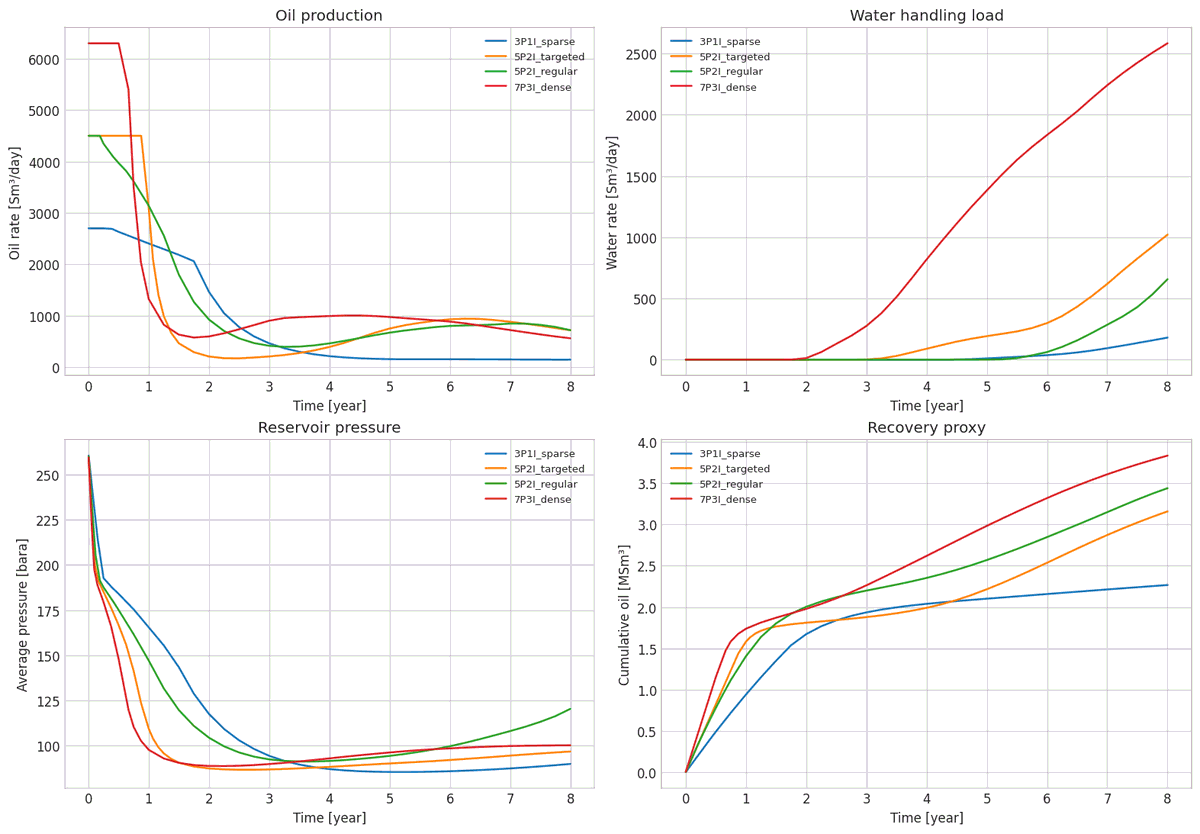

In [15]:
reservoir_figure, reservoir_axes = plt.subplots(
    2,
    2,
    figsize=(13.0, 9.0),
    constrained_layout=True,
)

for scenario_name, reservoir_history in reservoir_histories.items():
    time_years = reservoir_history["time_days"] / DAYS_PER_YEAR
    reservoir_axes[0, 0].plot(
        time_years,
        reservoir_history["oil_rate_Sm3_day"],
        label=scenario_name,
    )
    reservoir_axes[0, 1].plot(
        time_years,
        reservoir_history["water_rate_Sm3_day"],
        label=scenario_name,
    )
    reservoir_axes[1, 0].plot(
        time_years,
        reservoir_history["field_pressure_bara"],
        label=scenario_name,
    )
    reservoir_axes[1, 1].plot(
        time_years,
        reservoir_history["cumulative_oil_MSm3"],
        label=scenario_name,
    )

reservoir_axes[0, 0].set_ylabel("Oil rate [Sm³/day]")
reservoir_axes[0, 0].set_title("Oil production")
reservoir_axes[0, 1].set_ylabel("Water rate [Sm³/day]")
reservoir_axes[0, 1].set_title("Water handling load")
reservoir_axes[1, 0].set_ylabel("Average pressure [bara]")
reservoir_axes[1, 0].set_title("Reservoir pressure")
reservoir_axes[1, 1].set_ylabel("Cumulative oil [MSm³]")
reservoir_axes[1, 1].set_title("Recovery proxy")

for axis in reservoir_axes.ravel():
    axis.set_xlabel("Time [year]")
    axis.legend(fontsize=8)

plt.show()


## OPM restart-state inspection for the targeted case

Reading the final unified restart file verifies that the decision is supported by
cell-level pressure and saturation, not only summary curves. The map overlays
producer and injector locations on water saturation and permeability.


In [16]:
RESTART_SCENARIO = "5P2I_targeted"
restart_directory = OUTPUT_DIRECTORY / RESTART_SCENARIO
restart_stem = RESTART_SCENARIO.upper()
reservoir_grid = EGrid(
    str(restart_directory / f"{restart_stem}.EGRID")
)
initialization_file = EclFile(
    str(restart_directory / f"{restart_stem}.INIT")
)
restart_file = ERst(
    str(restart_directory / f"{restart_stem}.UNRST")
)

grid_nx, grid_ny, grid_nz = [
    int(dimension_value)
    for dimension_value in reservoir_grid.dimension
]
active_cell_count = int(reservoir_grid.active_cells)
restart_steps = [
    int(report_step)
    for report_step in restart_file.report_steps
]
final_restart_step = restart_steps[-1]


def active_array_to_cube(active_values):
    active_array = np.asarray(active_values, dtype=float)
    return active_array.reshape(grid_nz, grid_ny, grid_nx)


final_pressure_cube_bara = active_array_to_cube(
    restart_file["PRESSURE", final_restart_step]
)
final_water_saturation_cube = active_array_to_cube(
    restart_file["SWAT", final_restart_step]
)
final_gas_saturation_cube = active_array_to_cube(
    restart_file["SGAS", final_restart_step]
)
final_oil_saturation_cube = (
    1.0
    - final_water_saturation_cube
    - final_gas_saturation_cube
)

restart_audit = pd.DataFrame(
    {
        "quantity": [
            "grid dimensions",
            "active cells",
            "restart report states",
            "final pressure minimum",
            "final pressure maximum",
            "final water saturation maximum",
            "final gas saturation maximum",
            "final oil saturation minimum",
        ],
        "value": [
            f"{grid_nx} × {grid_ny} × {grid_nz}",
            active_cell_count,
            len(restart_steps),
            final_pressure_cube_bara.min(),
            final_pressure_cube_bara.max(),
            final_water_saturation_cube.max(),
            final_gas_saturation_cube.max(),
            final_oil_saturation_cube.min(),
        ],
        "unit": [
            "cells",
            "count",
            "count",
            "bara",
            "bara",
            "fraction",
            "fraction",
            "fraction",
        ],
    }
)
display(restart_audit)


,quantity,value,unit
0,grid dimensions,16 × 16 × 3,cells
1,active cells,768,count
2,restart report states,33,count
3,final pressure minimum,84.569382,bara
4,final pressure maximum,160.534851,bara
5,final water saturation maximum,0.879627,fraction
6,final gas saturation maximum,0.656084,fraction
7,final oil saturation minimum,0.120373,fraction


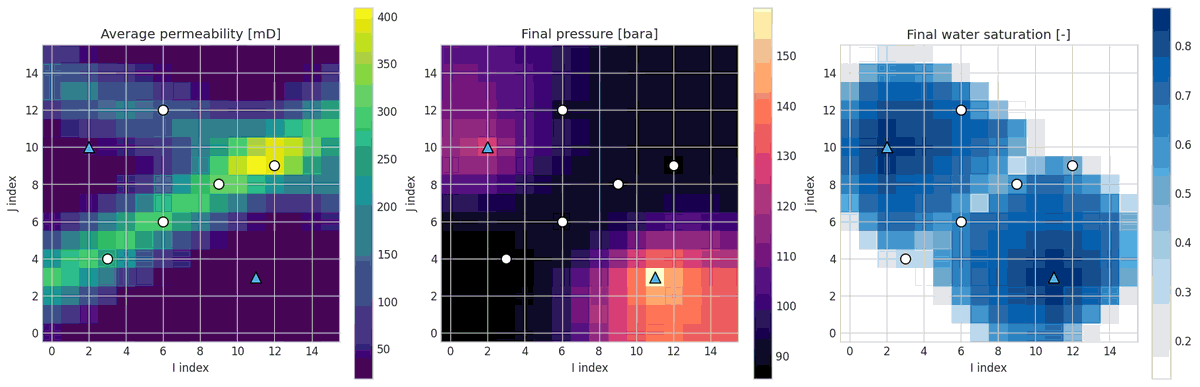

In [17]:
restart_map_figure, restart_map_axes = plt.subplots(
    1,
    3,
    figsize=(15.0, 4.8),
    constrained_layout=True,
)
restart_maps = [
    (
        permeability_cube_md.mean(axis=0),
        "Average permeability [mD]",
        "viridis",
    ),
    (
        final_pressure_cube_bara.mean(axis=0),
        "Final pressure [bara]",
        "magma",
    ),
    (
        final_water_saturation_cube.mean(axis=0),
        "Final water saturation [-]",
        "Blues",
    ),
]

targeted_definition = DEVELOPMENT_SCENARIOS[RESTART_SCENARIO]
for axis, (map_values, title, color_map) in zip(
    restart_map_axes,
    restart_maps,
):
    image = axis.imshow(
        map_values,
        origin="lower",
        cmap=color_map,
    )
    for i_index, j_index in targeted_definition["producers"]:
        axis.scatter(
            i_index - 1,
            j_index - 1,
            marker="o",
            s=80,
            facecolor="white",
            edgecolor="black",
        )
    for i_index, j_index in targeted_definition["injectors"]:
        axis.scatter(
            i_index - 1,
            j_index - 1,
            marker="^",
            s=100,
            facecolor="#56B4E9",
            edgecolor="black",
        )
    axis.set_title(title)
    axis.set_xlabel("I index")
    axis.set_ylabel("J index")
    restart_map_figure.colorbar(image, ax=axis)

plt.show()


## Quantitative placement diagnostics

The placement score combines permeability contacted by producers, injector-to-
producer spacing, and areal coverage. It is diagnostic only; OPM production and
economics remain the decision evidence.


In [18]:
placement_diagnostic_rows = []
for scenario_name, scenario_definition in DEVELOPMENT_SCENARIOS.items():
    producer_locations = np.asarray(
        scenario_definition["producers"],
        dtype=float,
    )
    injector_locations = np.asarray(
        scenario_definition["injectors"],
        dtype=float,
    )
    producer_permeabilities = np.asarray(
        [
            permeability_at_location(tuple(location.astype(int)))
            for location in producer_locations
        ]
    )
    injector_distances = []
    for producer_location in producer_locations:
        distance_to_injectors = np.linalg.norm(
            injector_locations - producer_location,
            axis=1,
        )
        injector_distances.append(distance_to_injectors.min())

    pairwise_producer_distances = []
    for producer_index in range(len(producer_locations)):
        for second_index in range(
            producer_index + 1,
            len(producer_locations),
        ):
            pairwise_producer_distances.append(
                np.linalg.norm(
                    producer_locations[producer_index]
                    - producer_locations[second_index]
                )
            )

    placement_diagnostic_rows.append(
        {
            "scenario": scenario_name,
            "mean producer k [mD]": producer_permeabilities.mean(),
            "mean nearest injector [cells]": np.mean(
                injector_distances
            ),
            "minimum producer spacing [cells]": np.min(
                pairwise_producer_distances
            ),
            "areal spread [cell²]": (
                np.ptp(producer_locations[:, 0])
                * np.ptp(producer_locations[:, 1])
            ),
        }
    )

placement_diagnostics = pd.DataFrame(
    placement_diagnostic_rows
).merge(
    reservoir_summary[
        ["scenario", "oil at 8 y [MSm3]", "peak water [Sm3/d]"]
    ],
    on="scenario",
)
display(placement_diagnostics)


,scenario,mean producer k [mD],mean nearest injector [cells],minimum producer spacing [cells],areal spread [cell²],oil at 8 y [MSm3],peak water [Sm3/d]
0,3P1I_sparse,126.466625,5.528942,8.944272,81.0,2.266023,180.047729
1,5P2I_targeted,391.996665,5.535936,3.162278,72.0,3.157231,1020.734802
2,5P2I_regular,85.330296,6.040569,5.000000,110.0,3.437891,657.092346
3,7P3I_dense,400.315854,4.777882,2.236068,80.0,3.832005,2583.918701


## Well deliverability and vertical-lift screening

A segmented screening model combines inflow and vertical lift. For each tubing size,
the required bottom-hole pressure is

$$

p_\mathrm{bh}
= p_\mathrm{wh}
+ \int_0^L \rho_m g\,dz
+ \int_0^L f\frac{\rho_m v_m^2}{2D}\,dL

$$

where $\rho_m$ and $v_m$ are no-slip mixture density and velocity. This is a
transparent pre-FEED model; final design requires calibrated IPR/VLP, completion
details, lift method, scale and sand risks, and transient well modelling.


In [19]:
def haaland_friction_factor(reynolds_number, relative_roughness):
    if reynolds_number < 2300.0:
        return 64.0 / max(reynolds_number, 1.0)
    inverse_root_friction = -1.8 * np.log10(
        (relative_roughness / 3.7) ** 1.11
        + 6.9 / reynolds_number
    )
    return 1.0 / inverse_root_friction**2


def vertical_lift_screen(
    oil_rate_sm3_day,
    gas_rate_sm3_day,
    water_rate_sm3_day,
    tubing_id_m,
    vertical_depth_m=2450.0,
    wellhead_pressure_bara=70.0,
):
    oil_volume_m3_s = (
        oil_rate_sm3_day * 1.18 / SECONDS_PER_DAY
    )
    water_volume_m3_s = (
        water_rate_sm3_day * 1.02 / SECONDS_PER_DAY
    )
    gas_volume_m3_s = (
        gas_rate_sm3_day * 0.018 / SECONDS_PER_DAY
    )
    total_volume_m3_s = (
        oil_volume_m3_s
        + water_volume_m3_s
        + gas_volume_m3_s
    )
    mixture_density_kg_m3 = (
        oil_volume_m3_s * 720.0
        + water_volume_m3_s * 990.0
        + gas_volume_m3_s * 65.0
    ) / max(total_volume_m3_s, 1.0e-12)
    mixture_viscosity_pa_s = 0.0035
    cross_section_m2 = math.pi * tubing_id_m**2 / 4.0
    velocity_m_s = total_volume_m3_s / cross_section_m2
    reynolds_number = (
        mixture_density_kg_m3
        * velocity_m_s
        * tubing_id_m
        / mixture_viscosity_pa_s
    )
    friction_factor = haaland_friction_factor(
        reynolds_number,
        1.5e-5 / tubing_id_m,
    )
    hydrostatic_drop_bar = (
        mixture_density_kg_m3
        * 9.80665
        * vertical_depth_m
        / 1.0e5
    )
    friction_drop_bar = (
        friction_factor
        * vertical_depth_m
        / tubing_id_m
        * mixture_density_kg_m3
        * velocity_m_s**2
        / 2.0
        / 1.0e5
    )
    required_bhp_bara = (
        wellhead_pressure_bara
        + hydrostatic_drop_bar
        + friction_drop_bar
    )
    return {
        "velocity_m_s": velocity_m_s,
        "mixture_density_kg_m3": mixture_density_kg_m3,
        "hydrostatic_drop_bar": hydrostatic_drop_bar,
        "friction_drop_bar": friction_drop_bar,
        "required_bhp_bara": required_bhp_bara,
    }


tubing_ids_m = [0.114, 0.140, 0.168]
well_screen_rows = []
for scenario_name, reservoir_history in reservoir_histories.items():
    scenario_definition = DEVELOPMENT_SCENARIOS[scenario_name]
    producer_count = len(scenario_definition["producers"])
    peak_index = int(
        reservoir_history["oil_rate_Sm3_day"].idxmax()
    )
    peak_row = reservoir_history.loc[peak_index]
    for tubing_id_m in tubing_ids_m:
        result = vertical_lift_screen(
            peak_row["oil_rate_Sm3_day"] / producer_count,
            peak_row["gas_rate_Sm3_day"] / producer_count,
            peak_row["water_rate_Sm3_day"] / producer_count,
            tubing_id_m,
        )
        well_screen_rows.append(
            {
                "scenario": scenario_name,
                "tubing ID [m]": tubing_id_m,
                "per-well oil [Sm3/d]": (
                    peak_row["oil_rate_Sm3_day"] / producer_count
                ),
                **result,
                "pressure margin [bar]": (
                    peak_row["field_pressure_bara"]
                    - result["required_bhp_bara"]
                ),
            }
        )

well_screen = pd.DataFrame(well_screen_rows)
well_screen["screen pass"] = (
    (well_screen["velocity_m_s"] < 12.0)
    & (well_screen["pressure margin [bar]"] > 10.0)
)
display(well_screen)


,scenario,tubing ID [m],per-well oil [Sm3/d],velocity_m_s,mixture_density_kg_m3,hydrostatic_drop_bar,friction_drop_bar,required_bhp_bara,pressure margin [bar],screen pass
0,3P1I_sparse,0.114,900.000000,5.331402,212.948713,51.163681,14.639231,135.802912,124.758002,True
1,3P1I_sparse,0.140,900.000000,3.535046,212.948713,51.163681,5.475597,126.639278,133.921635,True
2,3P1I_sparse,0.168,900.000000,2.454893,212.948713,51.163681,2.293000,123.456681,137.104232,True
3,5P2I_targeted,0.114,900.000000,5.331402,212.948698,51.163677,14.639229,135.802906,124.153301,True
4,5P2I_targeted,0.140,900.000000,3.535046,212.948698,51.163677,5.475597,126.639274,133.316934,True
5,5P2I_targeted,0.168,900.000000,2.454893,212.948698,51.163677,2.293000,123.456677,136.499530,True
6,5P2I_regular,0.114,900.000098,5.285808,214.225124,51.470355,14.484524,135.954879,69.416825,True
7,5P2I_regular,0.140,900.000098,3.504814,214.225124,51.470355,5.417867,126.888222,78.483482,True
8,5P2I_regular,0.168,900.000098,2.433899,214.225124,51.470355,2.268871,123.739226,81.632478,True
9,7P3I_dense,0.114,900.000000,5.331402,212.948696,51.163677,14.639230,135.802907,123.687724,True


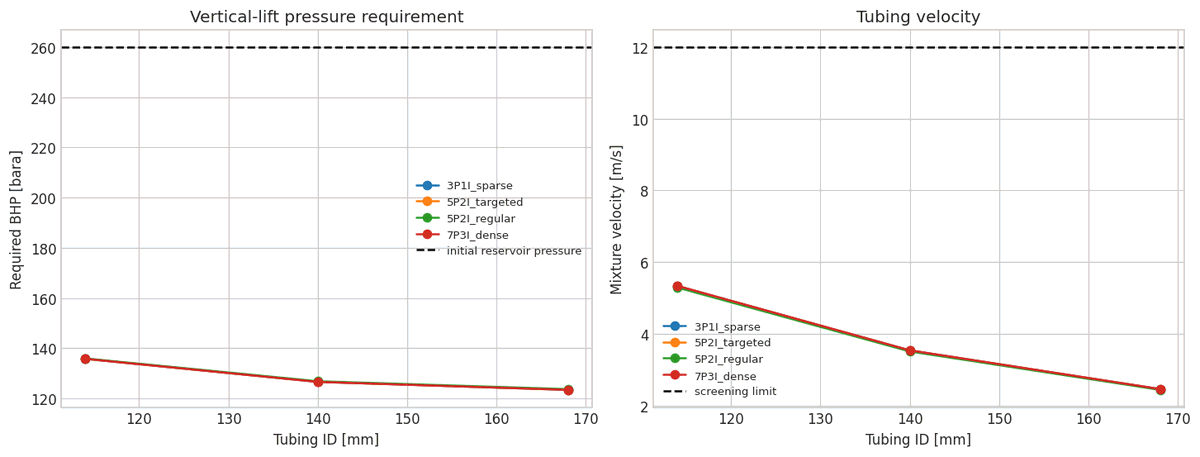

In [20]:
well_figure, well_axes = plt.subplots(
    1,
    2,
    figsize=(12.0, 4.5),
    constrained_layout=True,
)
for scenario_name in DEVELOPMENT_SCENARIOS:
    scenario_well_screen = well_screen.loc[
        well_screen["scenario"] == scenario_name
    ]
    well_axes[0].plot(
        scenario_well_screen["tubing ID [m]"] * 1000.0,
        scenario_well_screen["required_bhp_bara"],
        marker="o",
        label=scenario_name,
    )
    well_axes[1].plot(
        scenario_well_screen["tubing ID [m]"] * 1000.0,
        scenario_well_screen["velocity_m_s"],
        marker="o",
        label=scenario_name,
    )

well_axes[0].axhline(
    INITIAL_RESERVOIR_PRESSURE_BARA,
    color="black",
    linestyle="--",
    label="initial reservoir pressure",
)
well_axes[0].set_xlabel("Tubing ID [mm]")
well_axes[0].set_ylabel("Required BHP [bara]")
well_axes[0].set_title("Vertical-lift pressure requirement")
well_axes[1].axhline(
    12.0,
    color="black",
    linestyle="--",
    label="screening limit",
)
well_axes[1].set_xlabel("Tubing ID [mm]")
well_axes[1].set_ylabel("Mixture velocity [m/s]")
well_axes[1].set_title("Tubing velocity")
for axis in well_axes:
    axis.legend(fontsize=8)
plt.show()


## SURF network: templates, manifolds, flowlines, riser, and thermal margin

The network model applies Darcy–Weisbach pressure loss,

$$

\Delta p_f
= f\frac{L}{D}\frac{\rho_m v_m^2}{2}

$$

plus static head in the riser. A steady heat-loss model screens arrival temperature
and hydrate margin. The calculation includes well jumpers, manifold trunks, and a
riser; slugging, terrain accumulation, cooldown, restart, wax, and detailed hydrate
kinetics remain later-phase work.


In [21]:
SURF_CONCEPTS = {
    "two_manifolds_10in": {
        "manifold_count": 2,
        "trunk_id_m": 0.254,
        "jumper_id_m": 0.168,
        "heat_transfer_W_m2K": 4.0,
        "base_capex_MUSD": 80.0,
    },
    "three_manifolds_8in": {
        "manifold_count": 3,
        "trunk_id_m": 0.203,
        "jumper_id_m": 0.168,
        "heat_transfer_W_m2K": 3.0,
        "base_capex_MUSD": 125.0,
    },
}


def choose_manifold_locations(producer_locations, manifold_count):
    sorted_locations = sorted(
        producer_locations,
        key=lambda location: location[0],
    )
    location_groups = np.array_split(
        np.asarray(sorted_locations, dtype=float),
        manifold_count,
    )
    return [
        tuple(location_group.mean(axis=0))
        for location_group in location_groups
    ]


def pipe_segment_screen(
    mass_rate_kg_s,
    volume_rate_m3_s,
    density_kg_m3,
    viscosity_pa_s,
    length_m,
    internal_diameter_m,
    inlet_temperature_c,
    ambient_temperature_c,
    heat_transfer_W_m2K,
    elevation_change_m=0.0,
):
    area_m2 = math.pi * internal_diameter_m**2 / 4.0
    velocity_m_s = volume_rate_m3_s / area_m2
    reynolds_number = (
        density_kg_m3
        * velocity_m_s
        * internal_diameter_m
        / viscosity_pa_s
    )
    friction_factor = haaland_friction_factor(
        reynolds_number,
        1.5e-5 / internal_diameter_m,
    )
    friction_drop_bar = (
        friction_factor
        * length_m
        / internal_diameter_m
        * density_kg_m3
        * velocity_m_s**2
        / 2.0
        / 1.0e5
    )
    static_drop_bar = (
        density_kg_m3
        * 9.80665
        * elevation_change_m
        / 1.0e5
    )
    heat_capacity_J_kgK = 2600.0
    temperature_exponent = (
        heat_transfer_W_m2K
        * math.pi
        * internal_diameter_m
        * length_m
        / max(mass_rate_kg_s * heat_capacity_J_kgK, 1.0)
    )
    outlet_temperature_c = (
        ambient_temperature_c
        + (inlet_temperature_c - ambient_temperature_c)
        * math.exp(-temperature_exponent)
    )
    return {
        "velocity_m_s": velocity_m_s,
        "friction_drop_bar": friction_drop_bar,
        "static_drop_bar": static_drop_bar,
        "outlet_temperature_c": outlet_temperature_c,
    }


def evaluate_surf_concept(
    scenario_name,
    surf_name,
    surf_definition,
):
    reservoir_history = reservoir_histories[scenario_name]
    peak_index = int(
        reservoir_history["oil_rate_Sm3_day"].idxmax()
    )
    peak_row = reservoir_history.loc[peak_index]
    producer_locations = DEVELOPMENT_SCENARIOS[scenario_name][
        "producers"
    ]
    producer_count = len(producer_locations)
    manifold_locations = choose_manifold_locations(
        producer_locations,
        surf_definition["manifold_count"],
    )
    platform_location = np.array([-4.0, 8.0])

    oil_rate_m3_s = (
        peak_row["oil_rate_Sm3_day"]
        * 1.10
        / SECONDS_PER_DAY
    )
    water_rate_m3_s = (
        peak_row["water_rate_Sm3_day"]
        * 1.02
        / SECONDS_PER_DAY
    )
    gas_rate_m3_s = (
        peak_row["gas_rate_Sm3_day"]
        * 0.018
        / SECONDS_PER_DAY
    )
    total_volume_rate_m3_s = (
        oil_rate_m3_s + water_rate_m3_s + gas_rate_m3_s
    )
    mixture_density_kg_m3 = (
        oil_rate_m3_s * 720.0
        + water_rate_m3_s * 990.0
        + gas_rate_m3_s * 65.0
    ) / max(total_volume_rate_m3_s, 1.0e-12)
    mass_rate_kg_s = (
        total_volume_rate_m3_s * mixture_density_kg_m3
    )

    total_pressure_drop_bar = 0.0
    minimum_arrival_temperature_c = 65.0
    total_jumper_length_km = 0.0
    for producer_location in producer_locations:
        manifold_distances = [
            np.linalg.norm(
                np.asarray(producer_location)
                - np.asarray(manifold_location)
            )
            for manifold_location in manifold_locations
        ]
        jumper_length_m = (
            min(manifold_distances) * 0.10 + 0.35
        ) * 1000.0
        total_jumper_length_km += jumper_length_m / 1000.0
        jumper_result = pipe_segment_screen(
            mass_rate_kg_s / producer_count,
            total_volume_rate_m3_s / producer_count,
            mixture_density_kg_m3,
            0.0030,
            jumper_length_m,
            surf_definition["jumper_id_m"],
            65.0,
            4.0,
            surf_definition["heat_transfer_W_m2K"],
        )
        total_pressure_drop_bar += (
            jumper_result["friction_drop_bar"] / producer_count
        )
        minimum_arrival_temperature_c = min(
            minimum_arrival_temperature_c,
            jumper_result["outlet_temperature_c"],
        )

    total_trunk_length_km = 0.0
    trunk_pressure_drop_bar = 0.0
    trunk_arrival_temperature_c = 65.0
    for manifold_location in manifold_locations:
        trunk_length_m = (
            np.linalg.norm(
                np.asarray(manifold_location) - platform_location
            )
            * 0.10
            + 4.0
        ) * 1000.0
        total_trunk_length_km += trunk_length_m / 1000.0
        trunk_result = pipe_segment_screen(
            mass_rate_kg_s / len(manifold_locations),
            total_volume_rate_m3_s / len(manifold_locations),
            mixture_density_kg_m3,
            0.0030,
            trunk_length_m,
            surf_definition["trunk_id_m"],
            minimum_arrival_temperature_c,
            4.0,
            surf_definition["heat_transfer_W_m2K"],
        )
        trunk_pressure_drop_bar = max(
            trunk_pressure_drop_bar,
            trunk_result["friction_drop_bar"],
        )
        trunk_arrival_temperature_c = min(
            trunk_arrival_temperature_c,
            trunk_result["outlet_temperature_c"],
        )

    riser_result = pipe_segment_screen(
        mass_rate_kg_s,
        total_volume_rate_m3_s,
        mixture_density_kg_m3,
        0.0030,
        350.0,
        surf_definition["trunk_id_m"],
        trunk_arrival_temperature_c,
        6.0,
        surf_definition["heat_transfer_W_m2K"],
        elevation_change_m=120.0,
    )
    total_pressure_drop_bar += (
        trunk_pressure_drop_bar
        + riser_result["friction_drop_bar"]
        + riser_result["static_drop_bar"]
    )
    topside_arrival_temperature_c = (
        riser_result["outlet_temperature_c"]
    )
    arrival_pressure_bara = 70.0 - total_pressure_drop_bar
    hydrate_screen_temperature_c = (
        4.0 + 0.095 * max(arrival_pressure_bara - 20.0, 0.0)
    )
    hydrate_margin_c = (
        topside_arrival_temperature_c
        - hydrate_screen_temperature_c
    )
    flowline_capex_MUSD = (
        1.5 * total_jumper_length_km
        + 2.5 * total_trunk_length_km
    )
    capex_MUSD = (
        surf_definition["base_capex_MUSD"]
        + flowline_capex_MUSD
    )
    return {
        "scenario": scenario_name,
        "SURF concept": surf_name,
        "manifolds": len(manifold_locations),
        "jumper length [km]": total_jumper_length_km,
        "trunk length [km]": total_trunk_length_km,
        "pressure drop [bar]": total_pressure_drop_bar,
        "arrival pressure [bara]": arrival_pressure_bara,
        "arrival temperature [°C]": topside_arrival_temperature_c,
        "hydrate margin [°C]": hydrate_margin_c,
        "SURF CAPEX [MUSD]": capex_MUSD,
        "manifold locations": manifold_locations,
    }


surf_results = pd.DataFrame(
    [
        evaluate_surf_concept(
            scenario_name,
            surf_name,
            surf_definition,
        )
        for scenario_name in DEVELOPMENT_SCENARIOS
        for surf_name, surf_definition in SURF_CONCEPTS.items()
    ]
)
display(
    surf_results.drop(columns=["manifold locations"])
)


,scenario,SURF concept,manifolds,jumper length [km],trunk length [km],pressure drop [bar],arrival pressure [bara],arrival temperature [°C],hydrate margin [°C],SURF CAPEX [MUSD]
0,3P1I_sparse,two_manifolds_10in,2,2.079563,10.777457,4.685809,65.314191,40.897106,32.592258,110.062988
1,3P1I_sparse,three_manifolds_8in,3,1.050000,16.013534,5.546025,64.453975,44.470422,36.247294,166.608834
2,5P2I_targeted,two_manifolds_10in,2,3.098885,10.557797,7.002750,62.997250,48.430388,40.345649,111.042819
3,5P2I_targeted,three_manifolds_8in,3,2.610555,15.968045,9.872281,60.127719,50.694750,42.882617,168.835944
4,5P2I_regular,two_manifolds_10in,2,4.476622,10.593566,7.255640,62.744360,47.372950,39.312236,113.198850
5,5P2I_regular,three_manifolds_8in,3,3.953269,15.974458,10.083514,59.916486,49.688170,41.896104,170.866049
6,7P3I_dense,two_manifolds_10in,2,4.164581,10.453659,10.273193,59.726807,51.638392,43.864345,112.381018
7,7P3I_dense,three_manifolds_8in,3,3.659337,15.754735,15.512263,54.487737,54.019564,46.743229,169.875844


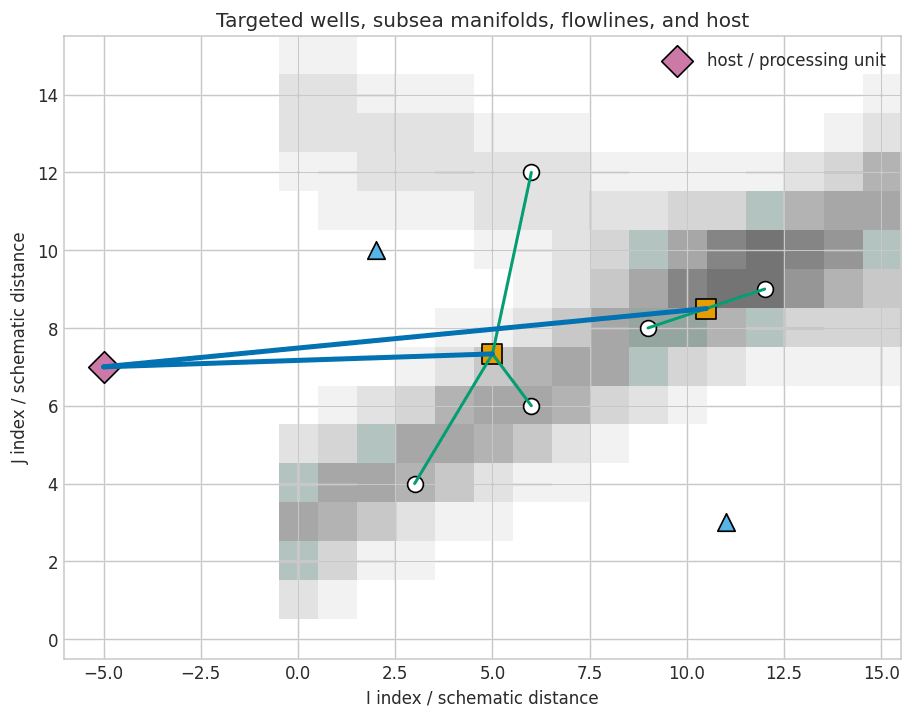

In [22]:
selected_map_scenario = "5P2I_targeted"
selected_surf_name = "two_manifolds_10in"
selected_surf_row = surf_results.loc[
    (surf_results["scenario"] == selected_map_scenario)
    & (surf_results["SURF concept"] == selected_surf_name)
].iloc[0]

selected_producers = DEVELOPMENT_SCENARIOS[selected_map_scenario][
    "producers"
]
selected_injectors = DEVELOPMENT_SCENARIOS[selected_map_scenario][
    "injectors"
]
selected_manifolds = selected_surf_row["manifold locations"]
platform_location = np.array([-4.0, 8.0])

surf_map_figure, surf_map_axis = plt.subplots(
    figsize=(9.0, 7.0)
)
surf_map_axis.imshow(
    permeability_cube_md[0],
    origin="lower",
    cmap="Greys",
    alpha=0.55,
)
for producer_location in selected_producers:
    nearest_manifold = min(
        selected_manifolds,
        key=lambda manifold_location: np.linalg.norm(
            np.asarray(producer_location)
            - np.asarray(manifold_location)
        ),
    )
    surf_map_axis.plot(
        [producer_location[0] - 1, nearest_manifold[0] - 1],
        [producer_location[1] - 1, nearest_manifold[1] - 1],
        color="#009E73",
        linewidth=1.8,
    )
    surf_map_axis.scatter(
        producer_location[0] - 1,
        producer_location[1] - 1,
        s=90,
        facecolor="white",
        edgecolor="black",
    )
for injector_location in selected_injectors:
    surf_map_axis.scatter(
        injector_location[0] - 1,
        injector_location[1] - 1,
        marker="^",
        s=110,
        color="#56B4E9",
        edgecolor="black",
    )
for manifold_location in selected_manifolds:
    surf_map_axis.scatter(
        manifold_location[0] - 1,
        manifold_location[1] - 1,
        marker="s",
        s=140,
        color="#E69F00",
        edgecolor="black",
    )
    surf_map_axis.plot(
        [manifold_location[0] - 1, platform_location[0] - 1],
        [manifold_location[1] - 1, platform_location[1] - 1],
        color="#0072B2",
        linewidth=3.0,
    )
surf_map_axis.scatter(
    platform_location[0] - 1,
    platform_location[1] - 1,
    marker="D",
    s=180,
    color="#CC79A7",
    edgecolor="black",
    label="host / processing unit",
)
surf_map_axis.set_title(
    "Targeted wells, subsea manifolds, flowlines, and host"
)
surf_map_axis.set_xlabel("I index / schematic distance")
surf_map_axis.set_ylabel("J index / schematic distance")
surf_map_axis.legend()
plt.show()


## Convert OPM black-oil rates to characterized NeqSim feeds

Stock-tank oil and gas phases from the characterized fluid are scaled to the OPM
standard rates, mixed, and combined with produced water. The reconstruction preserves
the characterized heavy-end distribution and checks mass closure.


In [23]:
stock_oil_template = stock_tank_state.phaseToSystem("oil")
stock_gas_template = stock_tank_state.phaseToSystem("gas")

water_probe = jneqsim.thermo.system.SystemSrkEos(
    STANDARD_TEMPERATURE_C + 273.15,
    STANDARD_PRESSURE_BARA,
)
water_probe.addComponent("water", 1.0)
water_molar_mass_kg_mol = (
    water_probe.getComponent("water").getMolarMass()
)


def reconstruct_characterized_wellhead_fluid(
    oil_rate_sm3_day,
    gas_rate_sm3_day,
    water_rate_sm3_day,
    wellhead_temperature_c=65.0,
    wellhead_pressure_bara=70.0,
):
    stock_oil = stock_oil_template.clone()
    stock_gas = stock_gas_template.clone()
    stock_oil.setTotalFlowRate(
        max(float(oil_rate_sm3_day), 1.0e-6),
        "m3/day",
    )
    stock_gas.setTotalFlowRate(
        max(float(gas_rate_sm3_day), 1.0e-6),
        "Sm3/day",
    )

    clearProcess()
    oil_component_stream = stream(
        "OPM stock-tank oil component",
        stock_oil,
    )
    gas_component_stream = stream(
        "OPM surface-gas component",
        stock_gas,
    )
    recombination_mixer = mixer(
        "OPM black-oil to NeqSim characterized fluid"
    )
    recombination_mixer.addStream(oil_component_stream)
    recombination_mixer.addStream(gas_component_stream)
    runProcess()

    reconstructed_fluid = (
        recombination_mixer.getOutletStream().getFluid().clone()
    )
    hydrocarbon_mass_flow_kg_s = (
        reconstructed_fluid.getFlowRate("kg/sec")
    )
    water_mass_flow_kg_s = (
        float(water_rate_sm3_day)
        * stock_water_density_kg_m3
        / SECONDS_PER_DAY
    )
    water_molar_flow_mol_s = (
        water_mass_flow_kg_s / water_molar_mass_kg_mol
    )
    reconstructed_fluid.addComponent(
        "water",
        water_molar_flow_mol_s,
    )
    reconstructed_fluid.setMixingRule("classic")
    reconstructed_fluid.setMultiPhaseCheck(True)
    reconstructed_fluid.setTemperature(
        wellhead_temperature_c,
        "C",
    )
    reconstructed_fluid.setPressure(
        wellhead_pressure_bara,
        "bara",
    )
    TPflash(reconstructed_fluid)
    reconstructed_fluid.initPhysicalProperties()

    expected_mass_flow_kg_s = (
        hydrocarbon_mass_flow_kg_s + water_mass_flow_kg_s
    )
    mass_residual_kg_s = (
        reconstructed_fluid.getFlowRate("kg/sec")
        - expected_mass_flow_kg_s
    )
    return reconstructed_fluid, mass_residual_kg_s


## NeqSim three-stage topside model

The facilities model includes inlet choking and cooling, HP three-phase separation,
MP and LP oil flashes, three flash-gas compression trains, gas export pressure, oil
stabilization, produced-water removal, and mass/energy indicators. It is run at four
field-life snapshots from the selected reservoir case.


In [24]:
def run_topside_case(
    case_name,
    oil_rate_sm3_day,
    gas_rate_sm3_day,
    water_rate_sm3_day,
):
    feed_fluid, reconstruction_residual_kg_s = (
        reconstruct_characterized_wellhead_fluid(
            oil_rate_sm3_day,
            gas_rate_sm3_day,
            water_rate_sm3_day,
        )
    )

    clearProcess()
    process_feed = stream(
        f"{case_name} arrival fluid",
        feed_fluid,
    )
    inlet_choke = valve(
        f"{case_name} inlet choke",
        process_feed,
        p=55.0,
    )
    inlet_cooler = cooler(
        f"{case_name} inlet cooler",
        inlet_choke.getOutletStream(),
    )
    inlet_cooler.setOutTemperature(45.0 + 273.15)
    hp_separator = separator3phase(
        f"{case_name} HP three-phase separator",
        inlet_cooler.getOutletStream(),
    )

    mp_oil_valve = valve(
        f"{case_name} MP oil valve",
        hp_separator.getOilOutStream(),
        p=15.0,
    )
    mp_separator = separator(
        f"{case_name} MP separator",
        mp_oil_valve.getOutletStream(),
    )
    lp_oil_valve = valve(
        f"{case_name} LP oil valve",
        mp_separator.getLiquidOutStream(),
        p=2.0,
    )
    lp_separator = separator(
        f"{case_name} LP separator",
        lp_oil_valve.getOutletStream(),
    )

    hp_gas_compressor = compressor(
        f"{case_name} HP gas compressor",
        hp_separator.getGasOutStream(),
        pres=140.0,
    )
    mp_gas_compressor = compressor(
        f"{case_name} MP flash-gas compressor",
        mp_separator.getGasOutStream(),
        pres=140.0,
    )
    lp_gas_compressor = compressor(
        f"{case_name} LP flash-gas compressor",
        lp_separator.getGasOutStream(),
        pres=140.0,
    )
    for gas_compressor in [
        hp_gas_compressor,
        mp_gas_compressor,
        lp_gas_compressor,
    ]:
        gas_compressor.setIsentropicEfficiency(0.75)

    runProcess()

    gas_export_mass_kg_s = sum(
        gas_compressor.getOutletStream().getFlowRate("kg/sec")
        for gas_compressor in [
            hp_gas_compressor,
            mp_gas_compressor,
            lp_gas_compressor,
        ]
    )
    oil_export_mass_kg_s = (
        lp_separator.getLiquidOutStream().getFlowRate("kg/sec")
    )
    produced_water_mass_kg_s = (
        hp_separator.getWaterOutStream().getFlowRate("kg/sec")
    )
    feed_mass_kg_s = process_feed.getFlowRate("kg/sec")
    process_mass_residual_kg_s = (
        feed_mass_kg_s
        - gas_export_mass_kg_s
        - oil_export_mass_kg_s
        - produced_water_mass_kg_s
    )
    compressor_power_MW = sum(
        gas_compressor.getPower() / 1.0e6
        for gas_compressor in [
            hp_gas_compressor,
            mp_gas_compressor,
            lp_gas_compressor,
        ]
    )
    return {
        "case": case_name,
        "oil feed [Sm3/d]": oil_rate_sm3_day,
        "gas feed [Sm3/d]": gas_rate_sm3_day,
        "water feed [Sm3/d]": water_rate_sm3_day,
        "feed mass [kg/s]": feed_mass_kg_s,
        "export oil [kg/s]": oil_export_mass_kg_s,
        "export gas [kg/s]": gas_export_mass_kg_s,
        "produced water [kg/s]": produced_water_mass_kg_s,
        "compression [MW]": compressor_power_MW,
        "inlet cooling [MW]": inlet_cooler.getDuty() / 1.0e6,
        "mass residual [kg/s]": process_mass_residual_kg_s,
        "reconstruction residual [kg/s]": (
            reconstruction_residual_kg_s
        ),
    }


In [25]:
topside_reservoir_scenario = "5P2I_targeted"
topside_history = reservoir_histories[topside_reservoir_scenario]
topside_rows = []
snapshot_specs = [
    ("early plateau", 1),
    (
        "peak oil",
        int(topside_history["oil_rate_Sm3_day"].idxmax()),
    ),
    ("mid life", len(topside_history) // 2),
    ("late life", len(topside_history) - 1),
]
for snapshot_label, snapshot_index in snapshot_specs:
    snapshot_row = topside_history.iloc[snapshot_index]
    topside_rows.append(
        run_topside_case(
            snapshot_label,
            snapshot_row["oil_rate_Sm3_day"],
            snapshot_row["gas_rate_Sm3_day"],
            snapshot_row["water_rate_Sm3_day"],
        )
    )

topside_results = pd.DataFrame(topside_rows)
display(topside_results)


,case,oil feed [Sm3/d],gas feed [Sm3/d],water feed [Sm3/d],feed mass [kg/s],export oil [kg/s],export gas [kg/s],produced water [kg/s],compression [MW],inlet cooling [MW],mass residual [kg/s],reconstruction residual [kg/s]
0,early plateau,4500.000000,1.011027e+06,0.001037,13.700019,2.268876,11.431143,2.369003e-29,1.632261,-0.716885,-1.332268e-15,1.776357e-15
1,peak oil,4500.000000,1.011027e+06,0.000487,13.700012,2.268877,11.431136,2.369001e-29,1.632260,-0.716885,6.661338e-15,1.776357e-15
2,mid life,188.051010,1.997590e+05,0.085130,2.610137,0.333525,2.276612,4.701629e-30,0.316005,-0.141008,-4.440892e-16,8.881784e-16
3,late life,717.605957,9.932741e+04,1020.734802,13.172227,0.265830,1.119910,1.178649e+01,0.163019,-1.224866,2.273737e-13,-1.776357e-15


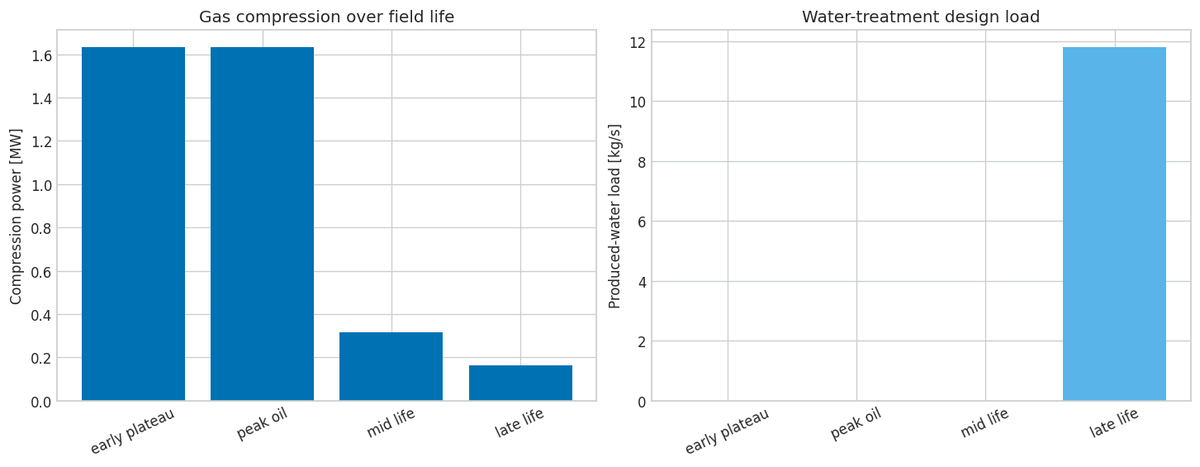

In [26]:
topside_figure, topside_axes = plt.subplots(
    1,
    2,
    figsize=(12.0, 4.6),
    constrained_layout=True,
)
topside_axes[0].bar(
    topside_results["case"],
    topside_results["compression [MW]"],
    color="#0072B2",
)
topside_axes[0].set_ylabel("Compression power [MW]")
topside_axes[0].set_title("Gas compression over field life")
topside_axes[0].tick_params(axis="x", rotation=25)

topside_axes[1].bar(
    topside_results["case"],
    topside_results["produced water [kg/s]"],
    color="#56B4E9",
)
topside_axes[1].set_ylabel("Produced-water load [kg/s]")
topside_axes[1].set_title("Water-treatment design load")
topside_axes[1].tick_params(axis="x", rotation=25)
plt.show()


## Topside concept and capacity alternatives

Two processing concepts are screened:

- `host_tieback`: lower modifications CAPEX, earlier first oil, constrained oil and
  water capacity;
- `leased_processing_unit`: higher CAPEX and schedule, but greater capacity and more
  operating flexibility.

Limits and costs are assumptions, not Volve actuals.


In [27]:
TOPSIDE_CONCEPTS = {
    "host_tieback": {
        "oil_capacity_sm3_day": 3800.0,
        "water_capacity_sm3_day": 3600.0,
        "gas_capacity_sm3_day": 4000000.0,
        "capex_MUSD": 90.0,
        "fixed_opex_MUSD_year": 18.0,
        "first_oil_year": 3.0,
    },
    "leased_processing_unit": {
        "oil_capacity_sm3_day": 7200.0,
        "water_capacity_sm3_day": 8000.0,
        "gas_capacity_sm3_day": 7000000.0,
        "capex_MUSD": 360.0,
        "fixed_opex_MUSD_year": 52.0,
        "first_oil_year": 4.0,
    },
}


def apply_capacity_limits(reservoir_history, topside_definition):
    capacity_factor = np.minimum.reduce(
        [
            np.ones(len(reservoir_history)),
            topside_definition["oil_capacity_sm3_day"]
            / np.maximum(
                reservoir_history["oil_rate_Sm3_day"],
                1.0,
            ),
            topside_definition["water_capacity_sm3_day"]
            / np.maximum(
                reservoir_history["water_rate_Sm3_day"],
                1.0,
            ),
            topside_definition["gas_capacity_sm3_day"]
            / np.maximum(
                reservoir_history["gas_rate_Sm3_day"],
                1.0,
            ),
        ]
    )
    limited_history = reservoir_history.copy()
    limited_history["capacity factor"] = np.clip(
        capacity_factor,
        0.0,
        1.0,
    )
    for rate_column in [
        "oil_rate_Sm3_day",
        "gas_rate_Sm3_day",
        "water_rate_Sm3_day",
    ]:
        limited_history[rate_column] *= limited_history[
            "capacity factor"
        ]
    return limited_history


capacity_rows = []
for scenario_name, reservoir_history in reservoir_histories.items():
    for topside_name, topside_definition in TOPSIDE_CONCEPTS.items():
        limited_history = apply_capacity_limits(
            reservoir_history,
            topside_definition,
        )
        capacity_rows.append(
            {
                "scenario": scenario_name,
                "topside": topside_name,
                "minimum capacity factor": limited_history[
                    "capacity factor"
                ].min(),
                "constrained report states": int(
                    (
                        limited_history["capacity factor"] < 0.999
                    ).sum()
                ),
                "peak limited oil [Sm3/d]": limited_history[
                    "oil_rate_Sm3_day"
                ].max(),
            }
        )

capacity_table = pd.DataFrame(capacity_rows)
display(capacity_table)


,scenario,topside,minimum capacity factor,constrained report states,peak limited oil [Sm3/d]
0,3P1I_sparse,host_tieback,1.000000,0,2700.000000
1,3P1I_sparse,leased_processing_unit,1.000000,0,2700.000000
2,5P2I_targeted,host_tieback,0.844444,12,3800.000000
3,5P2I_targeted,leased_processing_unit,1.000000,0,4500.000000
4,5P2I_regular,host_tieback,0.844444,10,3800.000000
5,5P2I_regular,leased_processing_unit,1.000000,0,4500.000488
6,7P3I_dense,host_tieback,0.603175,10,3800.000000
7,7P3I_dense,leased_processing_unit,1.000000,0,6300.000000


## Integrated economics and concept optimization

The post-tax screening cash flow is discounted to the decision date:

$$

\mathrm{NPV}
= \sum_{t=0}^{N}
\frac{R_t - O_t - T_t - I_t}{(1+r)^t}

$$

where $R_t$ is revenue, $O_t$ is operating cost, $T_t$ is simplified tax,
$I_t$ is investment, and $r$ is the real discount rate. Norwegian petroleum tax
treatment is represented only by a transparent simplified 78% positive-taxable-income
approximation with six-year straight-line depreciation. It is not a tax model.


In [28]:
OIL_PRICE_USD_BBL = 80.0
GAS_PRICE_USD_SM3 = 0.20
DISCOUNT_RATE = 0.08
TAX_RATE = 0.78
VARIABLE_OPEX_USD_BOE = 6.0
PRODUCER_COST_MUSD = 35.0
INJECTOR_COST_MUSD = 25.0


def annualize_reservoir_history(reservoir_history):
    annual_rows = []
    for row_index in range(1, len(reservoir_history)):
        previous_row = reservoir_history.iloc[row_index - 1]
        current_row = reservoir_history.iloc[row_index]
        time_step_days = (
            current_row["time_days"] - previous_row["time_days"]
        )
        midpoint_days = 0.5 * (
            current_row["time_days"] + previous_row["time_days"]
        )
        production_year = int(midpoint_days // DAYS_PER_YEAR) + 1
        annual_rows.append(
            {
                "year": production_year,
                "oil_Sm3": (
                    0.5
                    * (
                        current_row["oil_rate_Sm3_day"]
                        + previous_row["oil_rate_Sm3_day"]
                    )
                    * time_step_days
                ),
                "gas_Sm3": (
                    0.5
                    * (
                        current_row["gas_rate_Sm3_day"]
                        + previous_row["gas_rate_Sm3_day"]
                    )
                    * time_step_days
                ),
                "water_Sm3": (
                    0.5
                    * (
                        current_row["water_rate_Sm3_day"]
                        + previous_row["water_rate_Sm3_day"]
                    )
                    * time_step_days
                ),
            }
        )
    return (
        pd.DataFrame(annual_rows)
        .groupby("year", as_index=False)
        .sum()
    )


def concept_cash_flow(
    reservoir_history,
    producer_count,
    injector_count,
    surf_capex_MUSD,
    topside_definition,
    oil_price_usd_bbl=OIL_PRICE_USD_BBL,
    capex_multiplier=1.0,
    opex_multiplier=1.0,
    reservoir_multiplier=1.0,
):
    limited_history = apply_capacity_limits(
        reservoir_history,
        topside_definition,
    )
    annual_volumes = annualize_reservoir_history(limited_history)
    annual_volumes["oil_Sm3"] *= reservoir_multiplier
    annual_volumes["gas_Sm3"] *= reservoir_multiplier

    well_capex_MUSD = (
        producer_count * PRODUCER_COST_MUSD
        + injector_count * INJECTOR_COST_MUSD
    )
    total_capex_MUSD = capex_multiplier * (
        well_capex_MUSD
        + surf_capex_MUSD
        + topside_definition["capex_MUSD"]
    )
    development_years = [0, 1, 2]
    capex_fractions = [0.18, 0.47, 0.35]
    cash_flow_rows = [
        {
            "year": year,
            "revenue_MUSD": 0.0,
            "opex_MUSD": 0.0,
            "tax_MUSD": 0.0,
            "capex_MUSD": total_capex_MUSD * capex_fraction,
            "net_cash_MUSD": (
                -total_capex_MUSD * capex_fraction
            ),
        }
        for year, capex_fraction in zip(
            development_years,
            capex_fractions,
        )
    ]

    annual_depreciation_MUSD = total_capex_MUSD / 6.0
    for _, annual_row in annual_volumes.iterrows():
        oil_revenue_MUSD = (
            annual_row["oil_Sm3"]
            * 6.28981
            * oil_price_usd_bbl
            / 1.0e6
        )
        gas_revenue_MUSD = (
            annual_row["gas_Sm3"]
            * GAS_PRICE_USD_SM3
            / 1.0e6
        )
        revenue_MUSD = oil_revenue_MUSD + gas_revenue_MUSD
        produced_boe = (
            annual_row["oil_Sm3"] * 6.28981
            + annual_row["gas_Sm3"] / 158.987
        )
        variable_opex_MUSD = (
            produced_boe
            * VARIABLE_OPEX_USD_BOE
            / 1.0e6
        )
        opex_MUSD = opex_multiplier * (
            topside_definition["fixed_opex_MUSD_year"]
            + variable_opex_MUSD
        )
        depreciation_MUSD = (
            annual_depreciation_MUSD
            if annual_row["year"] <= 6
            else 0.0
        )
        taxable_income_MUSD = max(
            revenue_MUSD - opex_MUSD - depreciation_MUSD,
            0.0,
        )
        tax_MUSD = TAX_RATE * taxable_income_MUSD
        net_cash_MUSD = (
            revenue_MUSD - opex_MUSD - tax_MUSD
        )
        cash_flow_rows.append(
            {
                "year": int(
                    annual_row["year"]
                    + topside_definition["first_oil_year"]
                    - 1
                ),
                "revenue_MUSD": revenue_MUSD,
                "opex_MUSD": opex_MUSD,
                "tax_MUSD": tax_MUSD,
                "capex_MUSD": 0.0,
                "net_cash_MUSD": net_cash_MUSD,
            }
        )

    cash_flow = pd.DataFrame(cash_flow_rows)
    cash_flow["discount factor"] = (
        1.0 + DISCOUNT_RATE
    ) ** cash_flow["year"]
    cash_flow["discounted cash_MUSD"] = (
        cash_flow["net_cash_MUSD"]
        / cash_flow["discount factor"]
    )
    npv_MUSD = cash_flow["discounted cash_MUSD"].sum()
    cumulative_cash = cash_flow["net_cash_MUSD"].cumsum()
    positive_years = cash_flow.loc[
        cumulative_cash >= 0.0,
        "year",
    ]
    payback_year = (
        float(positive_years.iloc[0])
        if len(positive_years)
        else np.nan
    )
    return {
        "NPV [MUSD]": npv_MUSD,
        "CAPEX [MUSD]": total_capex_MUSD,
        "payback [year]": payback_year,
        "cash flow": cash_flow,
    }


In [29]:
integrated_concept_rows = []
integrated_cash_flows = {}
for scenario_name, reservoir_history in reservoir_histories.items():
    scenario_definition = DEVELOPMENT_SCENARIOS[scenario_name]
    producer_count = len(scenario_definition["producers"])
    injector_count = len(scenario_definition["injectors"])
    for surf_name in SURF_CONCEPTS:
        surf_row = surf_results.loc[
            (surf_results["scenario"] == scenario_name)
            & (surf_results["SURF concept"] == surf_name)
        ].iloc[0]
        for topside_name, topside_definition in (
            TOPSIDE_CONCEPTS.items()
        ):
            concept_name = (
                f"{scenario_name} | {surf_name} | {topside_name}"
            )
            economic_result = concept_cash_flow(
                reservoir_history,
                producer_count,
                injector_count,
                surf_row["SURF CAPEX [MUSD]"],
                topside_definition,
            )
            integrated_cash_flows[concept_name] = economic_result[
                "cash flow"
            ]
            capacity_row = capacity_table.loc[
                (capacity_table["scenario"] == scenario_name)
                & (capacity_table["topside"] == topside_name)
            ].iloc[0]
            integrated_concept_rows.append(
                {
                    "concept": concept_name,
                    "reservoir scenario": scenario_name,
                    "SURF": surf_name,
                    "topside": topside_name,
                    "producers": producer_count,
                    "injectors": injector_count,
                    "arrival pressure [bara]": surf_row[
                        "arrival pressure [bara]"
                    ],
                    "hydrate margin [°C]": surf_row[
                        "hydrate margin [°C]"
                    ],
                    "minimum capacity factor": capacity_row[
                        "minimum capacity factor"
                    ],
                    "first oil [year]": topside_definition[
                        "first_oil_year"
                    ],
                    **{
                        key: value
                        for key, value in economic_result.items()
                        if key != "cash flow"
                    },
                }
            )

integrated_concepts = (
    pd.DataFrame(integrated_concept_rows)
    .sort_values("NPV [MUSD]", ascending=False)
    .reset_index(drop=True)
)
display(integrated_concepts)


,concept,reservoir scenario,SURF,topside,producers,injectors,arrival pressure [bara],hydrate margin [°C],minimum capacity factor,first oil [year],NPV [MUSD],CAPEX [MUSD],payback [year]
0,5P2I_regular | two_manifolds_10in | host_tieback,5P2I_regular,two_manifolds_10in,host_tieback,5,2,62.744360,39.312236,0.844444,3.0,81.887784,428.198850,6.0
1,5P2I_regular | three_manifolds_8in | host_tieback,5P2I_regular,three_manifolds_8in,host_tieback,5,2,59.916486,41.896104,0.844444,3.0,54.095817,485.866049,6.0
2,7P3I_dense | two_manifolds_10in | host_tieback,7P3I_dense,two_manifolds_10in,host_tieback,7,3,59.726807,43.864345,0.603175,3.0,30.397109,522.381018,7.0
3,3P1I_sparse | two_manifolds_10in | host_tieback,3P1I_sparse,two_manifolds_10in,host_tieback,3,1,65.314191,32.592258,1.000000,3.0,17.580222,330.062988,5.0
4,7P3I_dense | three_manifolds_8in | host_tieback,7P3I_dense,three_manifolds_8in,host_tieback,7,3,54.487737,46.743229,0.603175,3.0,7.398309,579.875844,7.0
5,5P2I_targeted | two_manifolds_10in | host_tieback,5P2I_targeted,two_manifolds_10in,host_tieback,5,2,62.997250,40.345649,0.844444,3.0,6.529915,426.042819,7.0
6,3P1I_sparse | three_manifolds_8in | host_tieback,3P1I_sparse,three_manifolds_8in,host_tieback,3,1,64.453975,36.247294,1.000000,3.0,-17.932033,386.608834,6.0
7,5P2I_targeted | three_manifolds_8in | host_tie...,5P2I_targeted,three_manifolds_8in,host_tieback,5,2,60.127719,42.882617,0.844444,3.0,-26.436035,483.835944,8.0
8,7P3I_dense | two_manifolds_10in | leased_proce...,7P3I_dense,two_manifolds_10in,leased_processing_unit,7,3,59.726807,43.864345,1.000000,4.0,-151.847081,792.381018,9.0
9,5P2I_regular | two_manifolds_10in | leased_pro...,5P2I_regular,two_manifolds_10in,leased_processing_unit,5,2,62.744360,39.312236,1.000000,4.0,-189.421785,698.198850,11.0


Recommended screening concept: 5P2I_regular | two_manifolds_10in | host_tieback


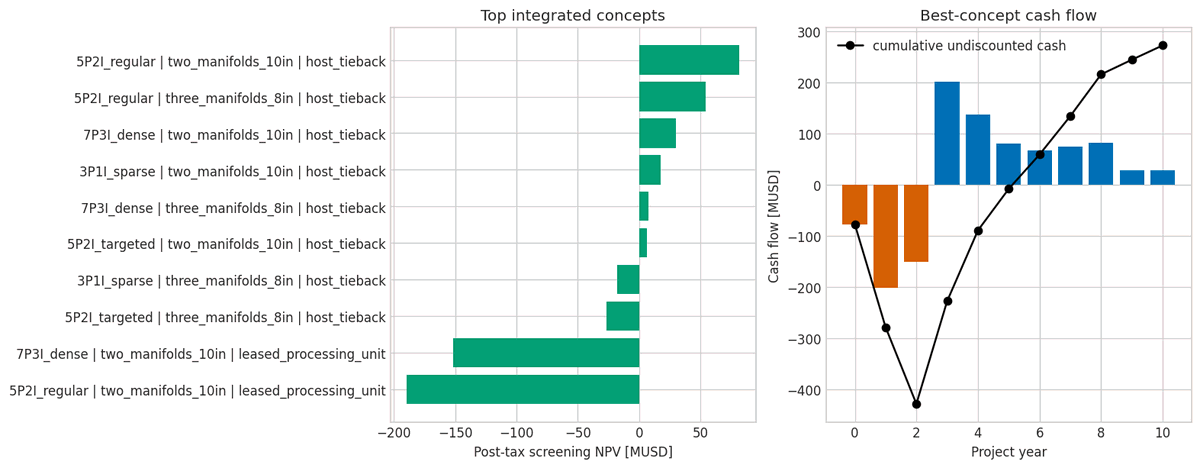

In [30]:
best_concept = integrated_concepts.iloc[0]
best_concept_name = best_concept["concept"]
best_cash_flow = integrated_cash_flows[best_concept_name]

concept_figure, concept_axes = plt.subplots(
    1,
    2,
    figsize=(13.0, 5.0),
    constrained_layout=True,
)
top_concepts = integrated_concepts.head(10).sort_values(
    "NPV [MUSD]"
)
concept_axes[0].barh(
    top_concepts["concept"],
    top_concepts["NPV [MUSD]"],
    color="#009E73",
)
concept_axes[0].set_xlabel("Post-tax screening NPV [MUSD]")
concept_axes[0].set_title("Top integrated concepts")

concept_axes[1].bar(
    best_cash_flow["year"],
    best_cash_flow["net_cash_MUSD"],
    color=np.where(
        best_cash_flow["net_cash_MUSD"] >= 0.0,
        "#0072B2",
        "#D55E00",
    ),
)
concept_axes[1].plot(
    best_cash_flow["year"],
    best_cash_flow["net_cash_MUSD"].cumsum(),
    color="black",
    marker="o",
    label="cumulative undiscounted cash",
)
concept_axes[1].set_xlabel("Project year")
concept_axes[1].set_ylabel("Cash flow [MUSD]")
concept_axes[1].set_title("Best-concept cash flow")
concept_axes[1].legend()
plt.show()

print(f"Recommended screening concept: {best_concept_name}")


## Break-even oil price and decision uncertainty

The deterministic optimum is stress-tested with reservoir, price, CAPEX, and OPEX
uncertainty. P10/P50/P90 refer to the NPV distribution, not reserves. Spearman rank
correlation gives a transparent sensitivity ranking.


In [31]:
selected_scenario_name = best_concept["reservoir scenario"]
selected_surf_name = best_concept["SURF"]
selected_topside_name = best_concept["topside"]
selected_scenario_definition = DEVELOPMENT_SCENARIOS[
    selected_scenario_name
]
selected_surf_capex = surf_results.loc[
    (surf_results["scenario"] == selected_scenario_name)
    & (surf_results["SURF concept"] == selected_surf_name),
    "SURF CAPEX [MUSD]",
].iloc[0]
selected_topside_definition = TOPSIDE_CONCEPTS[
    selected_topside_name
]


def selected_npv_at_oil_price(oil_price_usd_bbl):
    return concept_cash_flow(
        reservoir_histories[selected_scenario_name],
        len(selected_scenario_definition["producers"]),
        len(selected_scenario_definition["injectors"]),
        selected_surf_capex,
        selected_topside_definition,
        oil_price_usd_bbl=oil_price_usd_bbl,
    )["NPV [MUSD]"]


lower_price = 5.0
upper_price = 250.0
if (
    selected_npv_at_oil_price(lower_price)
    * selected_npv_at_oil_price(upper_price)
    < 0.0
):
    break_even_oil_price_usd_bbl = brentq(
        selected_npv_at_oil_price,
        lower_price,
        upper_price,
    )
else:
    break_even_oil_price_usd_bbl = np.nan

uncertainty_sample_count = 1200
uncertainty_samples = pd.DataFrame(
    {
        "oil price [USD/bbl]": random_generator.triangular(
            45.0,
            80.0,
            115.0,
            uncertainty_sample_count,
        ),
        "CAPEX multiplier": random_generator.lognormal(
            mean=0.0,
            sigma=0.18,
            size=uncertainty_sample_count,
        ),
        "OPEX multiplier": random_generator.triangular(
            0.82,
            1.0,
            1.28,
            uncertainty_sample_count,
        ),
        "reservoir multiplier": np.clip(
            random_generator.normal(
                1.0,
                0.16,
                uncertainty_sample_count,
            ),
            0.55,
            1.45,
        ),
    }
)

uncertainty_npvs = []
for _, uncertainty_row in uncertainty_samples.iterrows():
    uncertainty_result = concept_cash_flow(
        reservoir_histories[selected_scenario_name],
        len(selected_scenario_definition["producers"]),
        len(selected_scenario_definition["injectors"]),
        selected_surf_capex,
        selected_topside_definition,
        oil_price_usd_bbl=uncertainty_row[
            "oil price [USD/bbl]"
        ],
        capex_multiplier=uncertainty_row["CAPEX multiplier"],
        opex_multiplier=uncertainty_row["OPEX multiplier"],
        reservoir_multiplier=uncertainty_row[
            "reservoir multiplier"
        ],
    )
    uncertainty_npvs.append(uncertainty_result["NPV [MUSD]"])
uncertainty_samples["NPV [MUSD]"] = uncertainty_npvs

npv_percentiles = np.percentile(
    uncertainty_samples["NPV [MUSD]"],
    [10, 50, 90],
)
sensitivity_rows = []
for uncertainty_column in [
    "oil price [USD/bbl]",
    "CAPEX multiplier",
    "OPEX multiplier",
    "reservoir multiplier",
]:
    correlation, _ = spearmanr(
        uncertainty_samples[uncertainty_column],
        uncertainty_samples["NPV [MUSD]"],
    )
    sensitivity_rows.append(
        {
            "uncertainty": uncertainty_column,
            "Spearman correlation with NPV": correlation,
        }
    )
sensitivity_table = pd.DataFrame(sensitivity_rows).sort_values(
    "Spearman correlation with NPV"
)

uncertainty_summary = pd.DataFrame(
    {
        "metric": [
            "break-even oil price",
            "P10 NPV",
            "P50 NPV",
            "P90 NPV",
            "probability NPV > 0",
        ],
        "value": [
            break_even_oil_price_usd_bbl,
            npv_percentiles[0],
            npv_percentiles[1],
            npv_percentiles[2],
            np.mean(uncertainty_samples["NPV [MUSD]"] > 0.0),
        ],
        "unit": [
            "USD/bbl",
            "MUSD",
            "MUSD",
            "MUSD",
            "fraction",
        ],
    }
)
display(uncertainty_summary)
display(sensitivity_table)


,metric,value,unit
0,break-even oil price,59.378490,USD/bbl
1,P10 NPV,-40.580011,MUSD
2,P50 NPV,73.141466,MUSD
3,P90 NPV,179.896046,MUSD
4,probability NPV > 0,0.792500,fraction


,uncertainty,Spearman correlation with NPV
1,CAPEX multiplier,-0.474686
2,OPEX multiplier,-0.060862
3,reservoir multiplier,0.588437
0,oil price [USD/bbl],0.654687


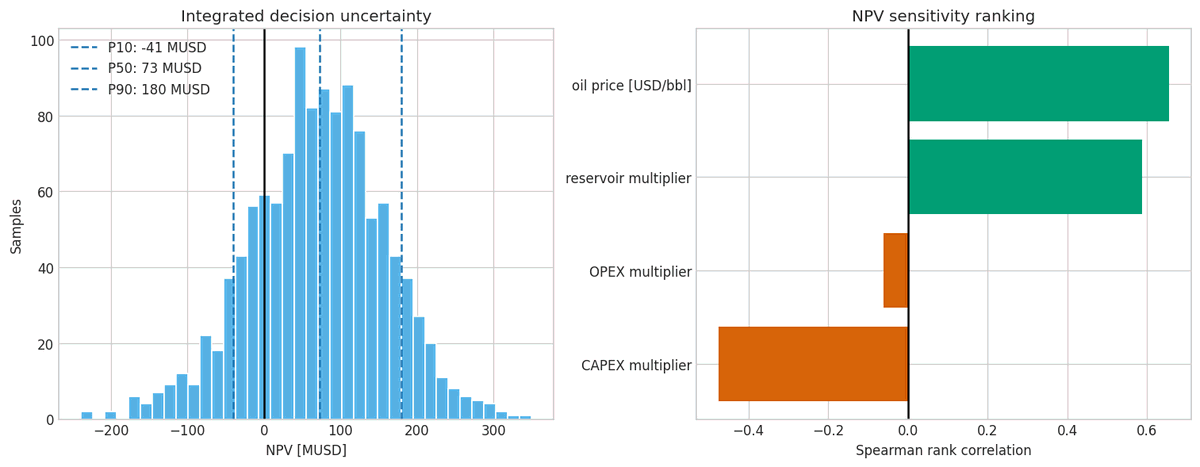

In [32]:
uncertainty_figure, uncertainty_axes = plt.subplots(
    1,
    2,
    figsize=(12.5, 4.8),
    constrained_layout=True,
)
uncertainty_axes[0].hist(
    uncertainty_samples["NPV [MUSD]"],
    bins=38,
    color="#56B4E9",
    edgecolor="white",
)
for percentile_value, percentile_name in zip(
    npv_percentiles,
    ["P10", "P50", "P90"],
):
    uncertainty_axes[0].axvline(
        percentile_value,
        linestyle="--",
        label=f"{percentile_name}: {percentile_value:.0f} MUSD",
    )
uncertainty_axes[0].axvline(0.0, color="black")
uncertainty_axes[0].set_xlabel("NPV [MUSD]")
uncertainty_axes[0].set_ylabel("Samples")
uncertainty_axes[0].set_title("Integrated decision uncertainty")
uncertainty_axes[0].legend()

uncertainty_axes[1].barh(
    sensitivity_table["uncertainty"],
    sensitivity_table["Spearman correlation with NPV"],
    color=np.where(
        sensitivity_table["Spearman correlation with NPV"] >= 0.0,
        "#009E73",
        "#D55E00",
    ),
)
uncertainty_axes[1].axvline(0.0, color="black")
uncertainty_axes[1].set_xlabel("Spearman rank correlation")
uncertainty_axes[1].set_title("NPV sensitivity ranking")
plt.show()


## Development schedule and decision gates

The schedule is a planning scaffold. A real project would link dependencies,
resource constraints, regulator and partner approvals, rig sequence, long-lead
equipment, commissioning, and uncertainty ranges.


,activity,start year,duration year
0,Volve data QA and model framing,0.0,0.6
1,PVT and reservoir calibration,0.2,1.0
2,Concept select and uncertainty,0.6,0.9
3,Appraisal / pilot decision,1.1,0.8
4,"FEED: wells, SURF, topsides",1.6,1.1
5,Long-lead procurement,2.2,1.2
6,Drill producers and injectors,2.4,1.5
7,SURF fabrication and installation,2.7,1.0
8,Topside modifications / unit,2.5,1.3
9,"Hook-up, commissioning, first oil",3.6,0.4


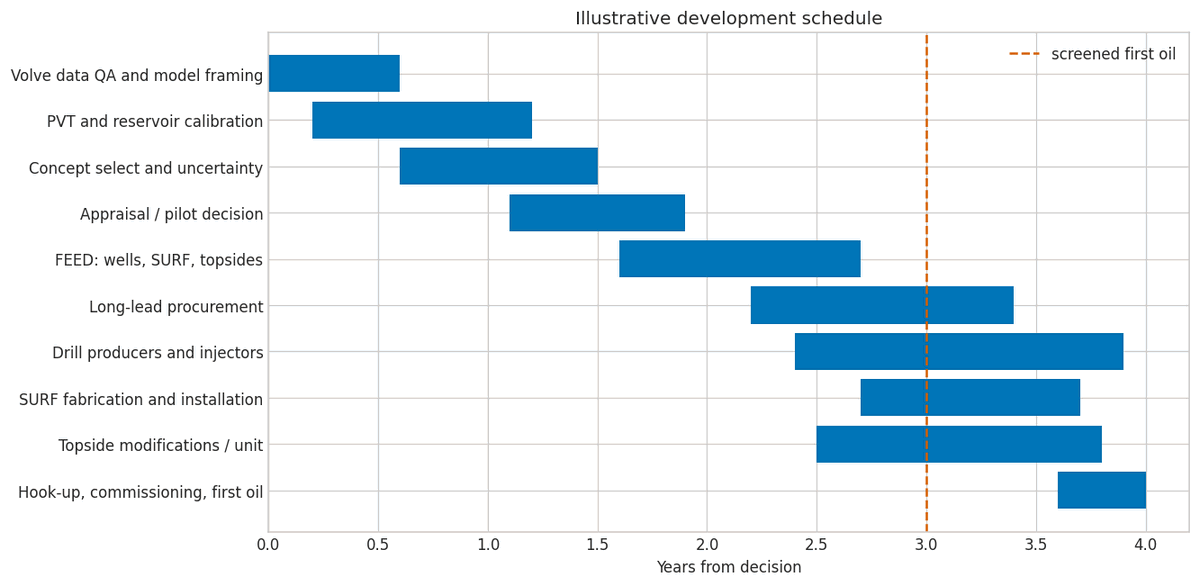

In [33]:
schedule = pd.DataFrame(
    [
        ("Volve data QA and model framing", 0.0, 0.6),
        ("PVT and reservoir calibration", 0.2, 1.0),
        ("Concept select and uncertainty", 0.6, 0.9),
        ("Appraisal / pilot decision", 1.1, 0.8),
        ("FEED: wells, SURF, topsides", 1.6, 1.1),
        ("Long-lead procurement", 2.2, 1.2),
        ("Drill producers and injectors", 2.4, 1.5),
        ("SURF fabrication and installation", 2.7, 1.0),
        ("Topside modifications / unit", 2.5, 1.3),
        ("Hook-up, commissioning, first oil", 3.6, 0.4),
    ],
    columns=["activity", "start year", "duration year"],
)
display(schedule)

schedule_figure, schedule_axis = plt.subplots(figsize=(11.0, 6.0))
schedule_axis.barh(
    schedule["activity"],
    schedule["duration year"],
    left=schedule["start year"],
    color="#0072B2",
)
schedule_axis.axvline(
    best_concept["first oil [year]"],
    color="#D55E00",
    linestyle="--",
    label="screened first oil",
)
schedule_axis.set_xlabel("Years from decision")
schedule_axis.set_title("Illustrative development schedule")
schedule_axis.invert_yaxis()
schedule_axis.legend()
plt.show()


## Executable engineering validation

The checks combine software execution, thermodynamic contracts, reservoir trends,
restart integrity, placement sensitivity, wells, SURF, topsides, capacity,
economics, and uncertainty. A failed check stops the notebook.


In [34]:
targeted_oil = reservoir_summary.loc[
    reservoir_summary["scenario"] == "5P2I_targeted",
    "oil at 8 y [MSm3]",
].iloc[0]
regular_oil = reservoir_summary.loc[
    reservoir_summary["scenario"] == "5P2I_regular",
    "oil at 8 y [MSm3]",
].iloc[0]

validation_checks = {
    "NeqSim version pinned": version("neqsim") == "3.16.0",
    "OPM Python version pinned": version("opm") == "2026.4",
    "OPM Flow version resolved": (
        flow_version_match.group(1) == "2026.04"
    ),
    "assay closes to 100 mol%": (
        abs(assay_sum_mol_percent - 100.0) < 1.0e-10
    ),
    "saturation methods agree": (
        abs(bubble_pressure_bara - saturation_pressure_bara) < 0.1
    ),
    "all PVT contracts pass": bool(pvt_contracts["passed"].all()),
    "four OPM alternatives executed": (
        len(reservoir_histories) == 4
    ),
    "all OPM runs returned success": (
        reservoir_run_table["return code"] == 0
    ).all(),
    "all OPM summaries exist": bool(
        reservoir_run_table["summary exists"].all()
    ),
    "all OPM restart files exist": bool(
        reservoir_run_table["restart exists"].all()
    ),
    "all reservoirs decline in pressure": all(
        history["field_pressure_bara"].iloc[-1]
        < history["field_pressure_bara"].iloc[0]
        for history in reservoir_histories.values()
    ),
    "all rates remain non-negative": all(
        (
            history[
                [
                    "oil_rate_Sm3_day",
                    "gas_rate_Sm3_day",
                    "water_rate_Sm3_day",
                ]
            ].to_numpy()
            >= 0.0
        ).all()
        for history in reservoir_histories.values()
    ),
    "placement changes recovery": (
        abs(targeted_oil - regular_oil) > 1.0e-4
    ),
    "restart grid dimensions correct": (
        (grid_nx, grid_ny, grid_nz)
        == (GRID_NX, GRID_NY, GRID_NZ)
    ),
    "restart saturation closes": (
        final_oil_saturation_cube.min() >= -1.0e-6
        and (
            final_water_saturation_cube
            + final_gas_saturation_cube
        ).max()
        <= 1.0 + 1.0e-6
    ),
    "at least one tubing option passes per case": all(
        well_screen.loc[
            well_screen["scenario"] == scenario_name,
            "screen pass",
        ].any()
        for scenario_name in DEVELOPMENT_SCENARIOS
    ),
    "SURF pressure losses positive": (
        surf_results["pressure drop [bar]"] > 0.0
    ).all(),
    "SURF arrival pressure positive": (
        surf_results["arrival pressure [bara]"] > 5.0
    ).all(),
    "SURF hydrate margins positive": (
        surf_results["hydrate margin [°C]"] > 0.0
    ).all(),
    "topside compression positive": (
        topside_results["compression [MW]"] > 0.0
    ).all(),
    "topside mass closes": (
        topside_results["mass residual [kg/s]"].abs().max()
        < 1.0e-8
    ),
    "rate reconstruction mass closes": (
        topside_results[
            "reconstruction residual [kg/s]"
        ].abs().max()
        < 1.0e-8
    ),
    "capacity factors are bounded": (
        capacity_table["minimum capacity factor"].between(
            0.0,
            1.0,
        )
    ).all(),
    "integrated concepts are finite": np.isfinite(
        integrated_concepts[
            ["NPV [MUSD]", "CAPEX [MUSD]"]
        ].to_numpy()
    ).all(),
    "best concept has finite break-even": np.isfinite(
        break_even_oil_price_usd_bbl
    ),
    "uncertainty sample complete": (
        len(uncertainty_samples) == uncertainty_sample_count
    ),
    "uncertainty NPV finite": np.isfinite(
        uncertainty_samples["NPV [MUSD]"]
    ).all(),
}

validation_table = pd.DataFrame(
    {
        "check": validation_checks.keys(),
        "passed": validation_checks.values(),
    }
)
display(validation_table)

failed_checks = validation_table.loc[
    ~validation_table["passed"],
    "check",
].tolist()
if failed_checks:
    raise AssertionError(f"Failed checks: {failed_checks}")

print(f"All {len(validation_checks)} engineering checks passed.")


All 27 engineering checks passed.


,check,passed
0,NeqSim version pinned,True
1,OPM Python version pinned,True
2,OPM Flow version resolved,True
3,assay closes to 100 mol%,True
4,saturation methods agree,True
5,all PVT contracts pass,True
6,four OPM alternatives executed,True
7,all OPM runs returned success,True
8,all OPM summaries exist,True
9,all OPM restart files exist,True


## Decision summary and reusable results

The machine-readable manifest records versions, selected concept, representative
reservoir and facilities results, economics, uncertainty, and validation count. It
can seed a later stage-gate report or a larger field-development optimization.


In [35]:
decision_summary = {
    "field_context": "Volve open-data teaching study",
    "data_boundary": (
        "Reduced Volve-inspired sector; not a history match"
    ),
    "neqsim_version": version("neqsim"),
    "opm_python_version": version("opm"),
    "opm_flow_version": flow_version_match.group(1),
    "reservoir_scenarios": len(DEVELOPMENT_SCENARIOS),
    "integrated_concepts": len(integrated_concepts),
    "recommended_concept": best_concept_name,
    "recommended_npv_MUSD": float(best_concept["NPV [MUSD]"]),
    "recommended_capex_MUSD": float(best_concept["CAPEX [MUSD]"]),
    "break_even_oil_price_USD_bbl": float(
        break_even_oil_price_usd_bbl
    ),
    "npv_P10_MUSD": float(npv_percentiles[0]),
    "npv_P50_MUSD": float(npv_percentiles[1]),
    "npv_P90_MUSD": float(npv_percentiles[2]),
    "probability_positive_npv": float(
        np.mean(uncertainty_samples["NPV [MUSD]"] > 0.0)
    ),
    "validation_checks_passed": int(
        validation_table["passed"].sum()
    ),
    "validation_checks_total": int(len(validation_table)),
}
decision_manifest_path = (
    OUTPUT_DIRECTORY / "field_development_decision_manifest.json"
)
decision_manifest_path.write_text(
    json.dumps(
        decision_summary,
        indent=2,
        sort_keys=True,
    )
    + "\n",
    encoding="utf-8",
)
display(
    pd.DataFrame(
        {
            "decision item": decision_summary.keys(),
            "value": decision_summary.values(),
        }
    )
)
print(json.dumps(decision_summary, indent=2, sort_keys=True))


{
  "break_even_oil_price_USD_bbl": 59.378489610537166,
  "data_boundary": "Reduced Volve-inspired sector; not a history match",
  "field_context": "Volve open-data teaching study",
  "integrated_concepts": 16,
  "neqsim_version": "3.16.0",
  "npv_P10_MUSD": -40.580010822076204,
  "npv_P50_MUSD": 73.14146586860568,
  "npv_P90_MUSD": 179.89604627762864,
  "opm_flow_version": "2026.04",
  "opm_python_version": "2026.4",
  "probability_positive_npv": 0.7925,
  "recommended_capex_MUSD": 428.1988498045723,
  "recommended_concept": "5P2I_regular | two_manifolds_10in | host_tieback",
  "recommended_npv_MUSD": 81.88778362233278,
  "reservoir_scenarios": 4,
  "validation_checks_passed": 27,
  "validation_checks_total": 27
}


,decision item,value
0,field_context,Volve open-data teaching study
1,data_boundary,Reduced Volve-inspired sector; not a history m...
2,neqsim_version,3.16.0
3,opm_python_version,2026.4
4,opm_flow_version,2026.04
5,reservoir_scenarios,4
6,integrated_concepts,16
7,recommended_concept,5P2I_regular | two_manifolds_10in | host_tieback
8,recommended_npv_MUSD,81.887784
9,recommended_capex_MUSD,428.19885


## Engineering interpretation

Read the result in dependency order:

1. Compare the two five-producer cases to quantify placement value before adding
   wells.
2. Check whether the dense case earns back extra wells and injectors after SURF and
   topside capacity are imposed.
3. Verify the selected tubing size has pressure and velocity margin at early peak and
   repeat with late-life water and gas fractions.
4. Confirm SURF arrival pressure and temperature leave margin for choking, separation,
   hydrate management, and restart.
5. Use the NeqSim snapshot loads to size separators, compressors, cooling, water
   treatment, flare, and export systems.
6. Treat NPV ranking as a screening recommendation only when its P10 downside,
   break-even price, schedule, and principal sensitivities are acceptable.


## Limitations and next engineering steps

Before a real concept decision:

- replace the reduced model with the licensed Volve Full Field deck or a calibrated
  subsurface ensemble;
- history match pressure, oil, gas, water, well events, and facility constraints;
- optimize trajectories and completions rather than grid-block locations;
- couple OPM well controls to calibrated IPR/VLP and lift strategy;
- run OLGA/LedaFlow-class transient assurance for terrain, slugging, cooldown,
  restart, hydrate, wax, erosion, and turndown;
- extend NeqSim topsides to detailed recompression, water treatment, gas dehydration,
  metering, flare, relief, blowdown, rotating-equipment maps, heat integration, and
  emissions;
- use project-specific cost, schedule, fiscal, abandonment, carbon-price, and host
  availability models; and
- run multi-realization robust optimization with decision rules and stage gates.


## Suggested exercises

1. Point `VOLVE_DATA_ROOT` at the Equinor download and compare its decks and result
   vectors with the reduced case.
2. Add a fifth placement with five producers chosen by an automated optimizer.
3. Replace fixed well targets with group oil, water, gas, and liquid constraints.
4. Add gas lift or ESP power and availability to the well model.
5. Connect the repository's native NeqSim `TwoFluidPipe` minimum-flow workflow to
   the late-life SURF cases.
6. Add a brownfield host with competing third-party production and capacity holdback.
7. Expand uncertainty to geological realizations, well failures, uptime, drilling
   duration, facility availability, and abandonment cost.


## Notebook validation evidence

Validation target: Python 3.12, NeqSim 3.16.0, OPM Python 2026.4, and OPM Flow
2026.04 on Ubuntu. The notebook must be executed top-to-bottom with stored outputs.
Source checks cover cell readability, balanced Colab math delimiters, single-backslash
LaTeX, output completeness, absence of stale errors, and catalog-link validity.

Evidence level: OPM Flow numerical execution plus restart inspection, NeqSim PVT and
process execution, conservation checks, physical bounds, same-basis scenario
comparisons, and deterministic uncertainty sampling. This is stronger than a
syntax-only example but weaker than a calibrated Volve history match.
